In [1]:
import os
parts='north'
input_dir1 = f"/storage/shadab/data/legacy_survey/dr9/{parts}/sweep/9.0/"
input_dir2 = f"/storage/shadab/data/legacy_survey/dr9/{parts}/sweep/9.0-photo-z/"
output_file = f"/user/animesh.sah/FP_CUTS/{parts}_cuts_v10_flux_w.fits"


In [2]:
os.listdir(input_dir1)

['download.log',
 'sweep-000m005-010p000.fits',
 'sweep-000p000-010p005.fits',
 'sweep-010m005-020p000.fits',
 'sweep-010p000-020p005.fits',
 'sweep-010p025-020p030.fits',
 'sweep-010p030-020p035.fits',
 'sweep-020p025-030p030.fits',
 'sweep-030m005-040p000.fits',
 'sweep-030p000-040p005.fits',
 'sweep-030p025-040p030.fits',
 'sweep-040m005-050p000.fits',
 'sweep-040p000-050p005.fits',
 'sweep-060p065-070p070.fits',
 'sweep-080p055-090p060.fits',
 'sweep-080p060-090p065.fits',
 'sweep-080p065-090p070.fits',
 'sweep-080p075-090p080.fits',
 'sweep-090p030-100p035.fits',
 'sweep-090p035-100p040.fits',
 'sweep-090p040-100p045.fits',
 'sweep-090p045-100p050.fits',
 'sweep-090p050-100p055.fits',
 'sweep-090p055-100p060.fits',
 'sweep-090p060-100p065.fits',
 'sweep-090p065-100p070.fits',
 'sweep-090p070-100p075.fits',
 'sweep-090p075-100p080.fits',
 'sweep-090p080-100p085.fits',
 'sweep-100p025-110p030.fits',
 'sweep-100p030-110p035.fits',
 'sweep-100p035-110p040.fits',
 'sweep-100p040-110p04

In [ ]:
for fname in os.listdir(input_dir1):
    print(fname)



In [ ]:
input_dir1 = f"/storage/shadab/data/legacy_survey/dr9/{parts}/sweep/9.0/"
input_dir2 = f"/storage/shadab/data/legacy_survey/dr9/{parts}/sweep/9.0-photo-z/"
output_file = f"/user/animesh.sah/FP_CUTS/{parts}_cuts_v10_flux_w.fits"
#os.makedirs(output_dir, exist_ok=True)

file_pairs = []
for fname in os.listdir(input_dir1):
    if fname.endswith(".fits") and "-pz" not in fname:
        pz_name = fname.replace(".fits", "-pz.fits")
        if os.path.exists(os.path.join(input_dir2, pz_name)):
            #output_path = os.path.join(output_dir, fname.replace(".fits", "_selected.fits"))
            file_pairs.append((os.path.join(input_dir1, fname),
                                os.path.join(input_dir2, pz_name)))

In [3]:
import pickle
import numpy as np
import fitsio
import matplotlib.pyplot as plt
from astropy.table import Table,vstack ,join
import scienceplots
from astropy.coordinates import SkyCoord
import astropy.units as u
plt.style.use(['science','notebook','grid'])

In [4]:
DR1_SGC=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/desi_dr1_SGC.fits')[1].read())
DR1_NGC=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/desi_dr1_NGC.fits')[1].read())
DR1=vstack([DR1_NGC,DR1_SGC])


In [5]:
#pickle.load('../data/infer_z_3D_gr_rz_zw1_v8_spec_highz_DES_COS_GAMArej.pkl')

with open('/user/animesh.sah/desi-legacy-survey-cross-correlations/data/infer_z_3D_gr_rz_zw1_v8_spec_highz_DES_COS_GAMArej.pkl','rb') as f:
    dat = pickle.load(f,encoding="latin1")

/tmp/ipykernel_594700/3147157169.py:4: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label="Counts summed over zw1")


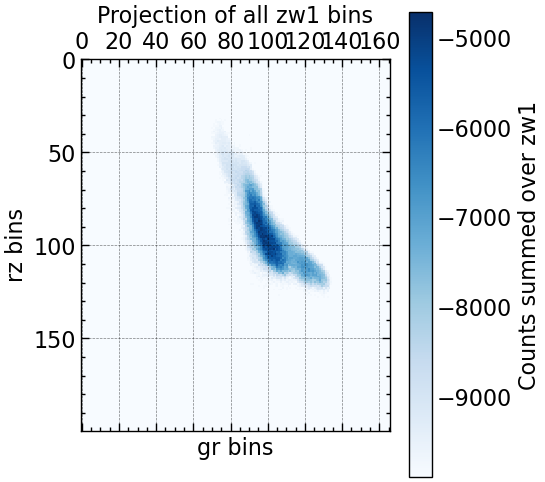

In [4]:
collapsed=np.sum(dat['matrix'],axis=0)

plt.matshow(collapsed.T, cmap='Blues')
plt.colorbar(label="Counts summed over zw1")
plt.title("Projection of all zw1 bins")
plt.xlabel("gr bins")
plt.ylabel("rz bins")
plt.show()

In [5]:
table_selection = Table(fitsio.FITS('table_match_final.fits')[1].read())
table_selection
unique_table_w1 = Table(fitsio.FITS('unique_table_w1.fits')[1].read())
# Find columns in unique_table_w1 that are not in table_selection
extra_cols = [col for col in unique_table_w1.colnames if col not in table_selection.colnames]

# Join and keep only the extra columns from unique_table_w1 (besides the common columns)
common = join(
    table_selection,
    unique_table_w1[extra_cols + ['BRICKID', 'OBJID', 'BRICKNAME']],
    keys=['BRICKID', 'OBJID', 'BRICKNAME'],
    join_type='inner'
)
xcoord = common['MAG_G'] - common['MAG_R']
ycoord = common['MAG_R'] - common['MAG_Z']
zcoord = common['MAG_Z'] - common['MAG_W1']
common['MAG_GR'] = xcoord
common['MAG_RZ'] = ycoord
common['MAG_ZW1'] = zcoord
common = common[(common['MAG_ZW1']>-8) & (common['MAG_ZW1']<5)]
xcoord = common['MAG_G'] - common['MAG_R']
ycoord = common['MAG_R'] - common['MAG_Z']
zcoord = common['MAG_Z'] - common['MAG_W1']
photo_z = common['Z_PHOT_MEDIAN']


OSError: FITSIO status = 104: could not open the named file
failed to find or open the following file: (ffopen)
table_match_final.fits


In [ ]:
coords_dr = SkyCoord(ra=DR1['RA']*u.deg, dec=DR1['DEC']*u.deg)
coords_legacy = SkyCoord(ra=common['RA']*u.deg, dec=common['DEC']*u.deg)
idx_legacy, idx_dr, sep2d, _ = coords_dr.search_around_sky(coords_legacy, 1.5*u.arcsec)
matched_dr = DR1[idx_dr]
matched_legacy = common[idx_legacy]


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
def two_d_hist(x,y):
    binx = np.linspace((min(x)), max(x), 50)
    biny = np.linspace((min(y)), max(y), 50)
    hist, xedges, yedges = np.histogram2d(x, y, bins=[binx, biny])
    return hist, xedges, yedges


In [ ]:
binx = np.linspace(min(matched_legacy['Z_PHOT_MEDIAN']), max(matched_legacy['Z_PHOT_MEDIAN']), 50)
biny = np.linspace(min(matched_dr['Z']), max(matched_dr['Z']), 50)
hist,xedges,yedges=np.histogram2d(matched_legacy['Z_PHOT_MEDIAN'], matched_dr['Z'], bins=(binx, biny))





array([[10.,  0.,  0., ...,  0.,  0.,  0.],
       [33.,  6.,  2., ...,  0.,  0.,  0.],
       [63., 42.,  2., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  2., ...,  1.,  0.,  0.]])

/tmp/ipykernel_593596/1364998457.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0, 0.5, 'Photo Z (Legacy)')

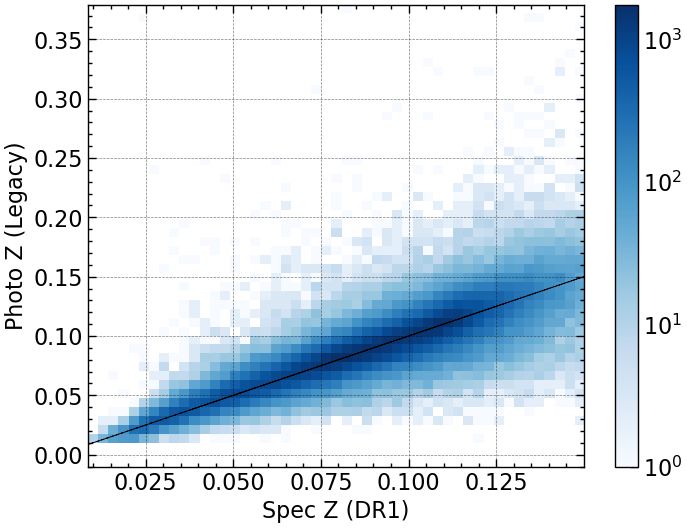

In [ ]:
from matplotlib.colors import LogNorm
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='Blues',norm=LogNorm())

plt.plot(matched_legacy['Z_PHOT_MEDIAN'],matched_legacy['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel('Photo Z (Legacy)')

/tmp/ipykernel_593596/2378058194.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0, 0.5, 'Photo Z (Legacy)')

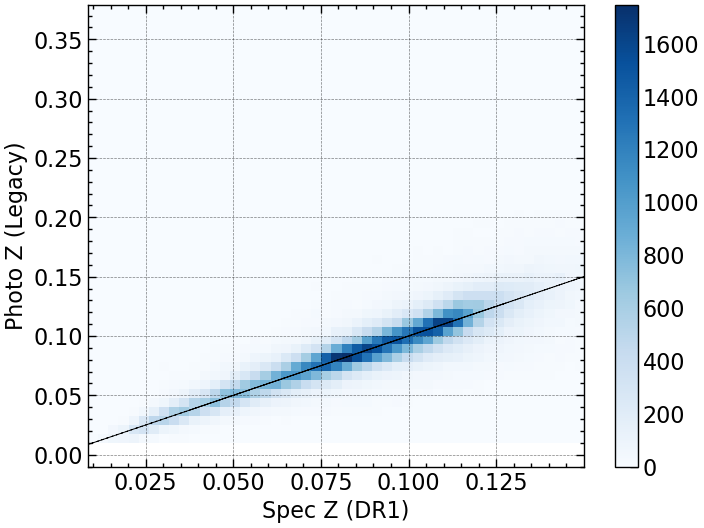

In [ ]:
from matplotlib.colors import LogNorm
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='Blues')

plt.plot(matched_legacy['Z_PHOT_MEDIAN'],matched_legacy['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar()
plt.xlabel('Spec Z (DR1)')
plt.ylabel('Photo Z (Legacy)')

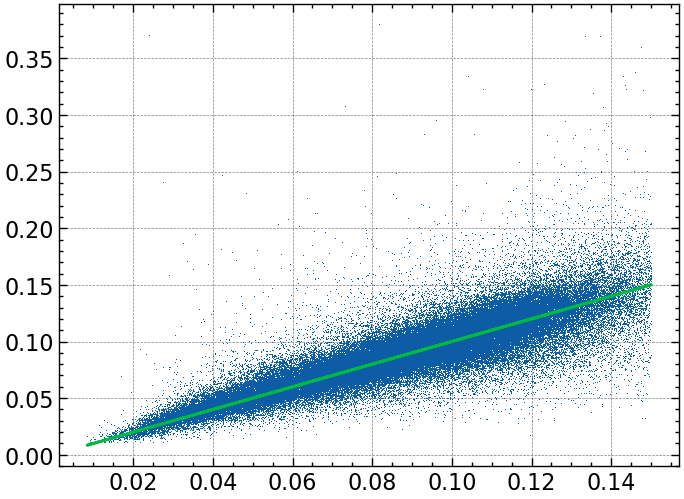

In [ ]:
plt.plot(matched_legacy['Z_PHOT_MEDIAN'],matched_dr['Z'],',')
plt.plot(matched_legacy['Z_PHOT_MEDIAN'],matched_legacy['Z_PHOT_MEDIAN'])

In [ ]:
specz = matched_dr['Z']
xcoord1 = matched_legacy['MAG_G'] - matched_legacy['MAG_R']
ycoord1 = matched_legacy['MAG_R'] - matched_legacy['MAG_Z']
zcoord1 = matched_legacy['MAG_Z'] - matched_legacy['MAG_W1']
z1 = matched_dr['Z']
matched_legacy['MAG_GR'] = xcoord1
matched_legacy['MAG_RZ'] = ycoord1
matched_legacy['MAG_ZW1'] = zcoord1

gr_bins  = np.linspace(xcoord.min(), xcoord.max(), 101)   # 20 bins
rz_bins  = np.linspace(ycoord.min(), ycoord.max(), 101)
zw1_bins = np.linspace(zcoord.min(), zcoord.max(), 101)

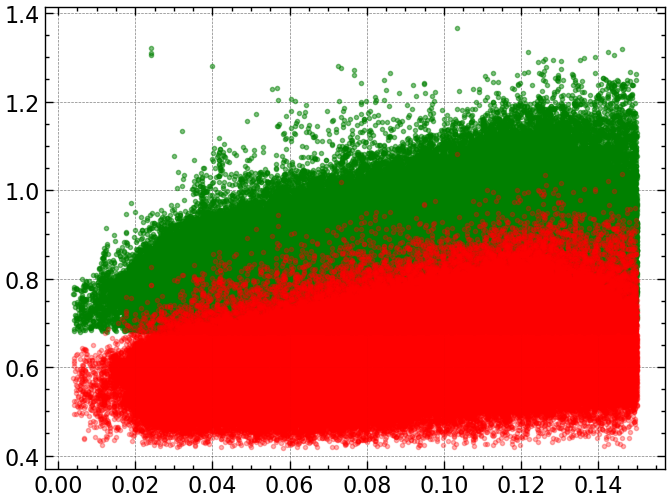

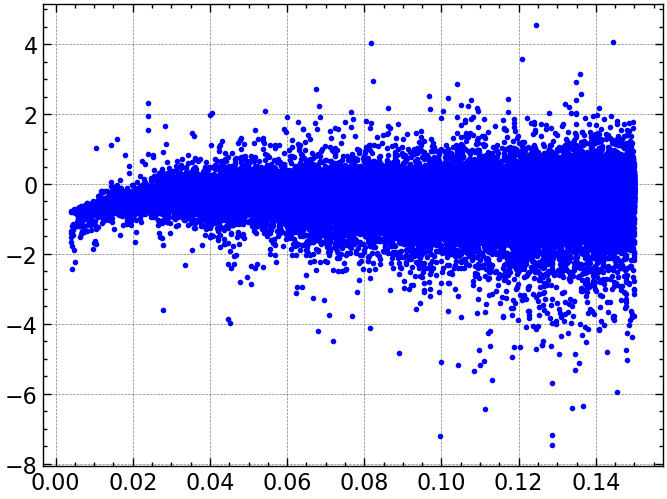

In [ ]:
plt.plot(common['Z_PHOT_MEDIAN'],common['MAG_GR'],'g.',alpha=0.5)
plt.plot(common['Z_PHOT_MEDIAN'],common['MAG_RZ'],'r.',alpha=0.3)
plt.show()
plt.plot(common['Z_PHOT_MEDIAN'],common['MAG_ZW1'],'b.')


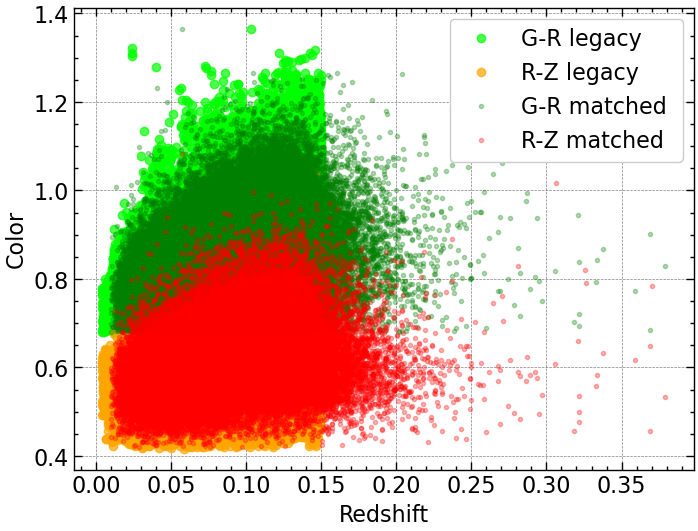

(-8.0, 5.0)

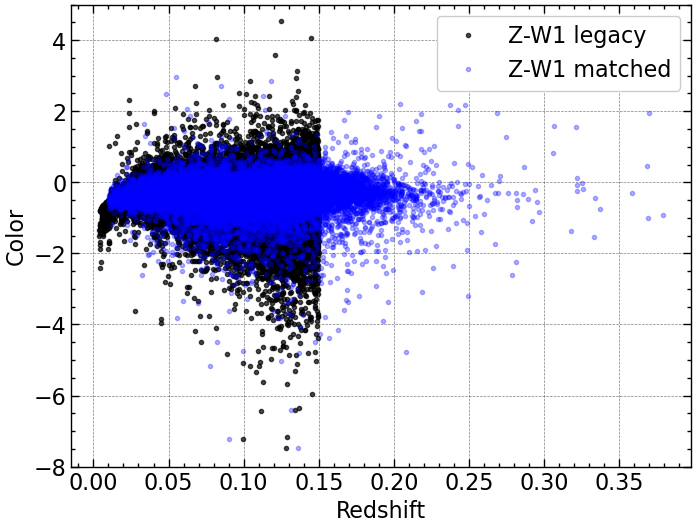

In [ ]:

plt.plot(common['Z_PHOT_MEDIAN'],common['MAG_GR'],'o',alpha=0.7,color='lime',label='G-R legacy')
plt.plot(common['Z_PHOT_MEDIAN'],common['MAG_RZ'],'o',color='orange',alpha=0.7,label='R-Z legacy'  )
plt.plot(matched_dr['Z'],matched_legacy['MAG_GR'],'g.',alpha=0.3,label='G-R matched ')
plt.plot(matched_dr['Z'],matched_legacy['MAG_RZ'],'r.',alpha=0.3,label='R-Z matched')
plt.xlabel('Redshift')
plt.ylabel('Color')

plt.legend()
plt.show()

plt.plot(common['Z_PHOT_MEDIAN'],common['MAG_ZW1'],'.',color='k',alpha=0.7,label='Z-W1 legacy')
plt.plot(matched_dr['Z'],matched_legacy['MAG_ZW1'],'b.',alpha=0.3,label='Z-W1 matched')
plt.legend()
plt.xlabel('Redshift')
plt.ylabel('Color')
plt.ylim(-8,5)

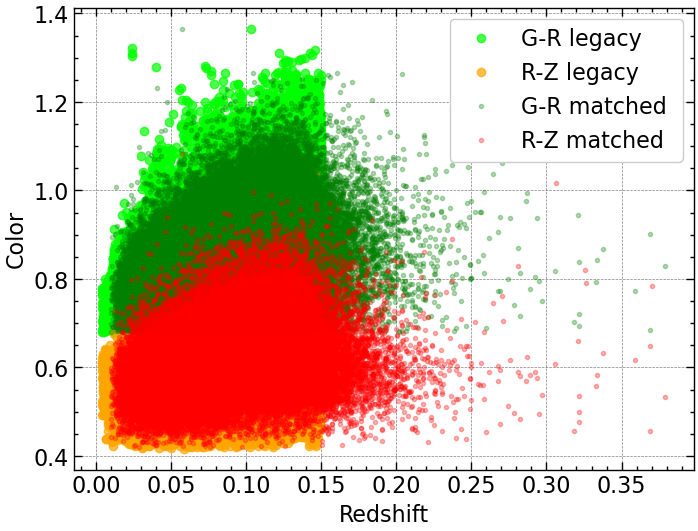

Text(0.5, 0, 'Redshift')

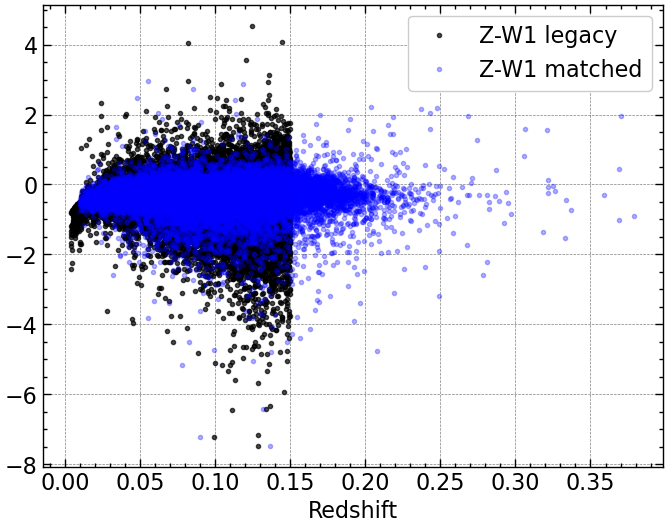

In [ ]:

plt.plot(common['Z_PHOT_MEDIAN'],common['MAG_GR'],'o',alpha=0.7,color='lime',label='G-R legacy')
plt.plot(common['Z_PHOT_MEDIAN'],common['MAG_RZ'],'o',color='orange',alpha=0.7,label='R-Z legacy'  )
plt.plot(matched_dr['Z'],matched_legacy['MAG_GR'],'g.',alpha=0.3,label='G-R matched ')
plt.plot(matched_dr['Z'],matched_legacy['MAG_RZ'],'r.',alpha=0.3,label='R-Z matched')
plt.xlabel('Redshift')
plt.ylabel('Color')

plt.legend()
plt.show()

plt.plot(common['Z_PHOT_MEDIAN'],common['MAG_ZW1'],'.',color='k',alpha=0.7,label='Z-W1 legacy')
plt.plot(matched_dr['Z'],matched_legacy['MAG_ZW1'],'b.',alpha=0.3,label='Z-W1 matched')
plt.legend()
plt.xlabel('Redshift')
# plt.ylabel('Color')
# plt.ylim(-8,5)

In [ ]:
binx = np.linspace((min(xx)), max(y), 50)
biny = np.linspace((min(y)), max(y), 50)
hist, xedges, yedges = np.histogram2d(x, y, bins=[binx, biny])

0.14999881

/tmp/ipykernel_593596/3255081274.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


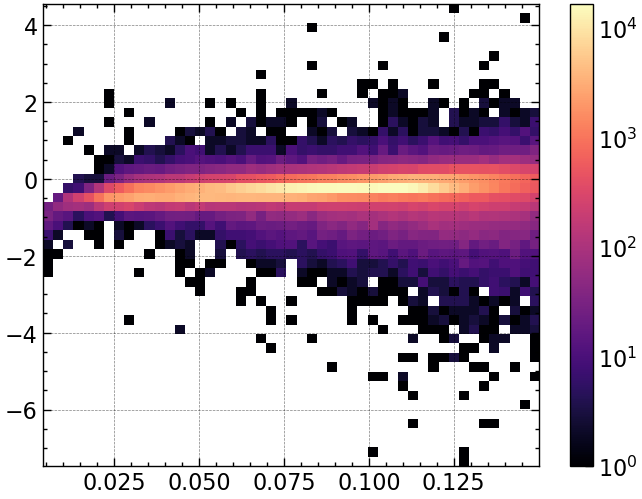

In [ ]:
xx =np.array(common['Z_PHOT_MEDIAN'])
yy= np.array(common['MAG_ZW1'])
num ,xxedges , yyedges = two_d_hist(xx,yy)
plt.imshow(num.T, origin='lower',
           extent=[xxedges[0], xxedges[-1], yyedges[0], yyedges[-1]],
           aspect='auto',cmap='magma',norm=LogNorm())
plt.colorbar()



/tmp/ipykernel_593596/1022744303.py:12: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()
/tmp/ipykernel_593596/1022744303.py:18: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


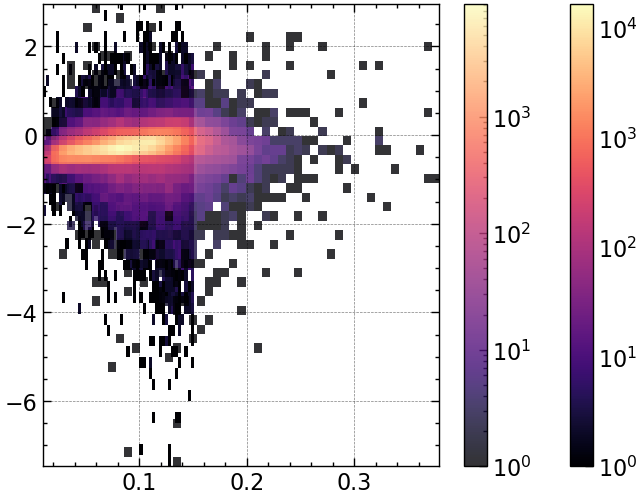

In [ ]:
xxx =np.array(matched_dr['Z'])
yyy= np.array(matched_legacy['MAG_ZW1'])
numm ,xxxedges , yyyedges = two_d_hist(xxx,yyy)


xx =np.array(common['Z_PHOT_MEDIAN'])
yy= np.array(common['MAG_ZW1'])
num ,xxedges , yyedges = two_d_hist(xx,yy)
plt.imshow(num.T, origin='lower',
           extent=[xxedges[0], xxedges[-1], yyedges[0], yyedges[-1]],
           aspect='auto',cmap='magma',norm=LogNorm())
plt.colorbar()


plt.imshow(numm.T, origin='lower',
           extent=[xxxedges[0], xxxedges[-1], yyyedges[0], yyyedges[-1]],
           aspect='auto',cmap='magma',alpha=0.8,norm=LogNorm())
plt.colorbar()


/tmp/ipykernel_4776/275516155.py:20: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


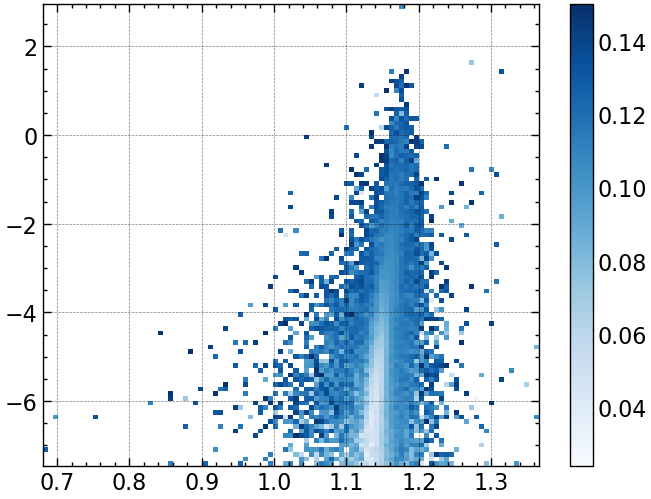

In [ ]:
from matplotlib.colors import LogNorm
y=matched_legacy['MAG_ZW1']
#y=matched_legacy['MAG_RZ']
x=matched_legacy['MAG_GR']


binx = np.linspace(min(x), max(x), 100)
biny = np.linspace(min(y), max(y), 100)

hist,xedges,yedges=np.histogram2d(x, y, bins=(binx, biny),weights=matched_legacy['Z_PHOT_MEDIAN'])
counts,_,_=np.histogram2d(x, y, bins=(binx, biny))
mask=counts>0
counts[~mask]=np.nan
mat=hist/counts
plt.imshow(mat, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='Blues')

# plt.plot(matched_legacy['Z_PHOT_MEDIAN'],matched_legacy['Z_PHOT_MEDIAN'],'k--',lw=0.7)
plt.colorbar()

(array([ 1.,  1.,  4.,  9., 11.,  5.,  4.,  5.,  5.,  9., 14.,  8.,  4.,
         3.,  1.,  0.,  0.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.05702264, 0.06201409, 0.06700554, 0.07199699, 0.07698844,
        0.08197989, 0.08697133, 0.09196278, 0.09695423, 0.10194568,
        0.10693713, 0.11192858, 0.11692003, 0.12191148, 0.12690293,
        0.13189438, 0.13688583, 0.14187728, 0.14686873, 0.15186018,
        0.15685163, 0.16184308, 0.16683453, 0.17182597, 0.17681742,
        0.18180887, 0.18680032, 0.19179177, 0.19678322, 0.20177467,
        0.20676612, 0.21175757, 0.21674902, 0.22174047, 0.22673192,
        0.23172337, 0.23671482, 0.24170627, 0.24669772, 0.25168916,
        0.25668061, 0.26167206, 0.26666351, 0.27165496, 0.27664641,
        0.28163786, 0.28662931, 0.29162076, 0.29661221, 0.30160366,
        0.30659511]),
 <BarContainer

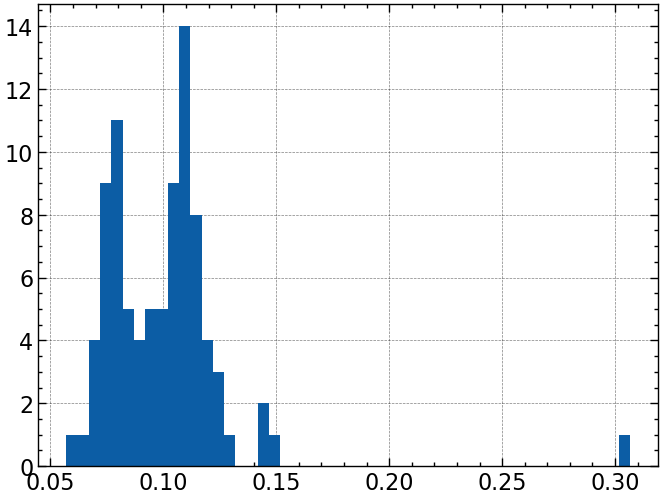

In [ ]:
sums,_=np.histogram(ycoord1, bins=rz_bins,weights=z1)
counts,_=np.histogram(ycoord1, bins=rz_bins)
plt.hist(sums[counts>0]/counts[counts>0],bins=50)

In [ ]:
coords = np.vstack([xcoord1, ycoord1, zcoord1]).T
counts, edges = np.histogramdd(coords, bins=[gr_bins, rz_bins, zw1_bins])
sums, _ = np.histogramdd(coords, bins=[gr_bins, rz_bins, zw1_bins], weights=z1)
# counts, edges = np.histogramdd(coords, bins=[30,30,30])
# sums, _ = np.histogramdd(coords, bins=[30,30,30], weights=z1)
zmatrix_matrix = np.zeros_like(sums)
mask = counts > 0
zmatrix_matrix[mask] = sums[mask] / counts[mask]  # average ztrue per bin
zmatrix_matrix[~mask]= np.nan
zmatrix1 = {
    'gr_bins': gr_bins,
    'rz_bins': rz_bins,
    'zw1_bins': zw1_bins,
    'matrix': zmatrix_matrix
}

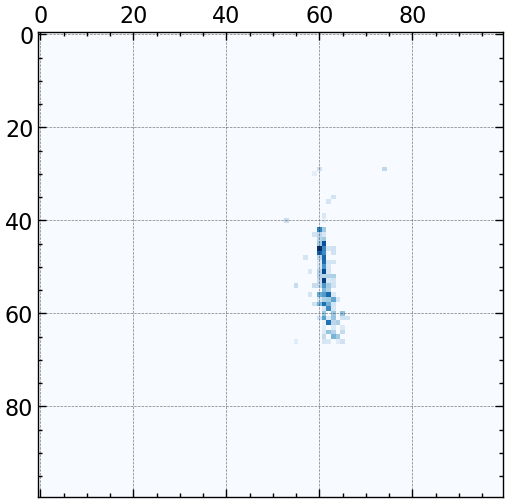

In [ ]:
plt.matshow(sums[56],cmap='Blues')


In [ ]:
from scipy.stats import binned_statistic_dd


In [ ]:
# stat, edges, binnumber = binned_statistic_dd(
#     sample=[xcoord1, ycoord1, zcoord1],
#     values=z1,
#     statistic='mean',
#     bins=[gr_bins, rz_bins, zw1_bins]
# )



In [ ]:
gr_bins

array([0.68000031, 0.68685846, 0.69371662, 0.70057478, 0.70743294,
       0.7142911 , 0.72114925, 0.72800741, 0.73486557, 0.74172373,
       0.74858189, 0.75544004, 0.7622982 , 0.76915636, 0.77601452,
       0.78287268, 0.78973083, 0.79658899, 0.80344715, 0.81030531,
       0.81716347, 0.82402163, 0.83087978, 0.83773794, 0.8445961 ,
       0.85145426, 0.85831242, 0.86517057, 0.87202873, 0.87888689,
       0.88574505, 0.89260321, 0.89946136, 0.90631952, 0.91317768,
       0.92003584, 0.926894  , 0.93375216, 0.94061031, 0.94746847,
       0.95432663, 0.96118479, 0.96804295, 0.9749011 , 0.98175926,
       0.98861742, 0.99547558, 1.00233374, 1.00919189, 1.01605005,
       1.02290821, 1.02976637, 1.03662453, 1.04348269, 1.05034084,
       1.057199  , 1.06405716, 1.07091532, 1.07777348, 1.08463163,
       1.09148979, 1.09834795, 1.10520611, 1.11206427, 1.11892242,
       1.12578058, 1.13263874, 1.1394969 , 1.14635506, 1.15321321,
       1.16007137, 1.16692953, 1.17378769, 1.18064585, 1.18750

In [ ]:
zmatrix_matrix

array([[[0.07234091, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.073069  , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.08939687, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.    

/tmp/ipykernel_4776/722182152.py:3: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


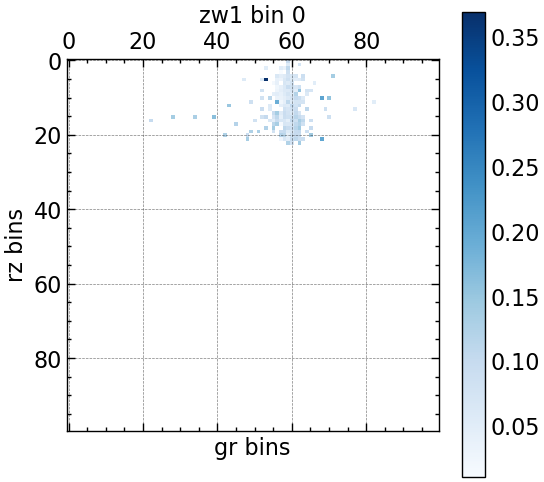

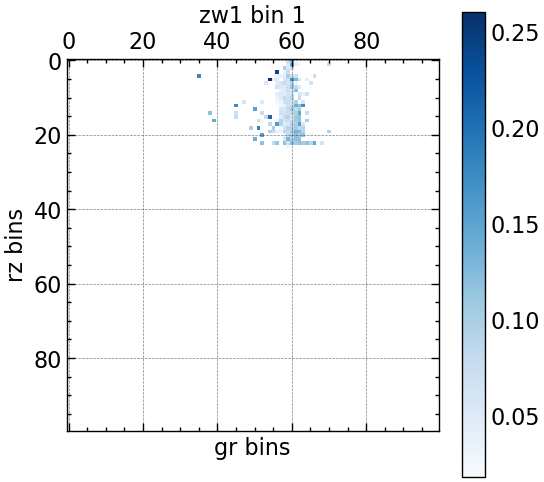

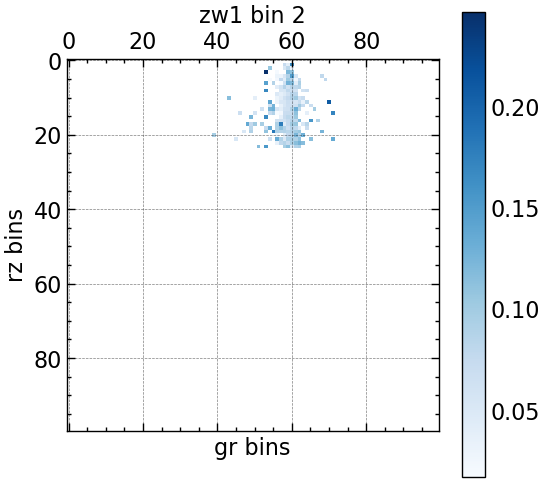

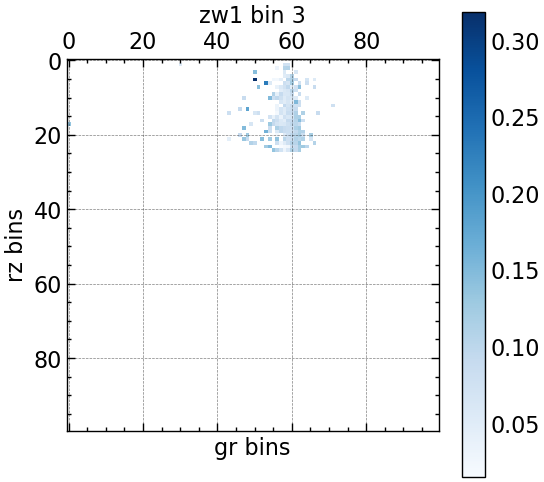

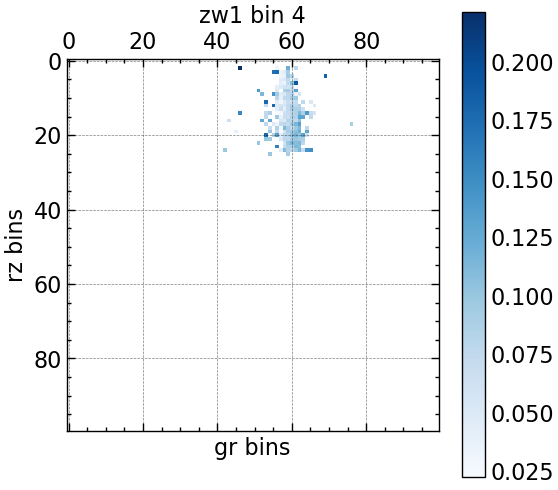

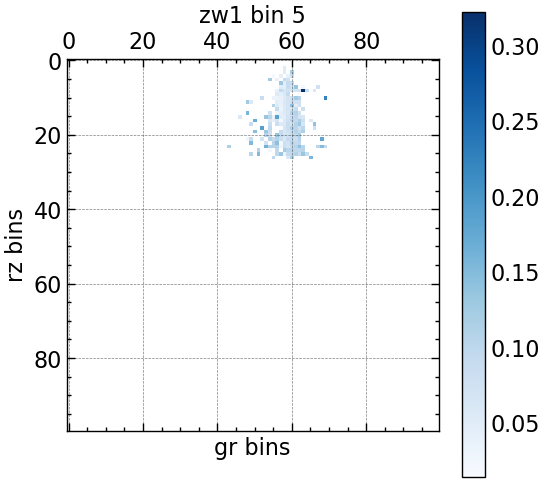

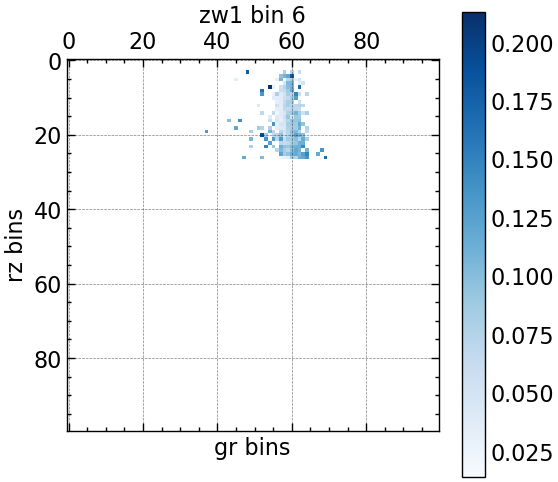

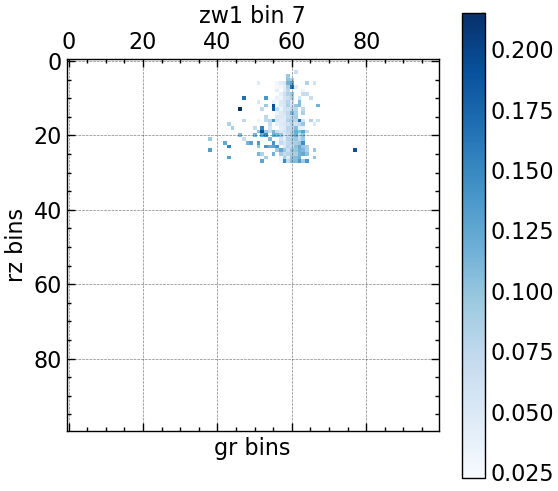

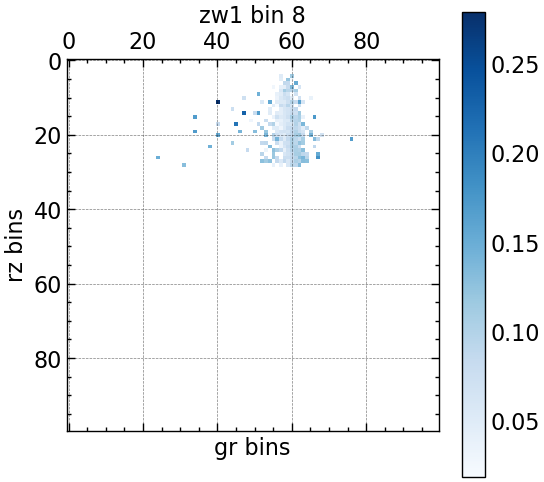

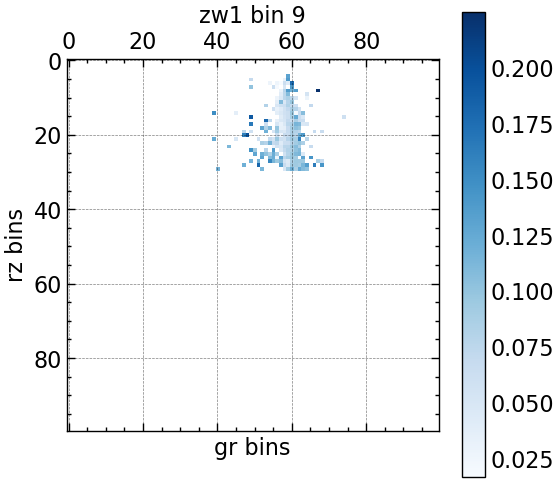

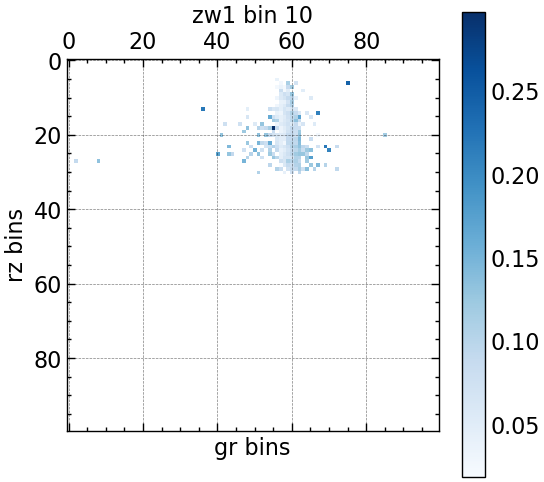

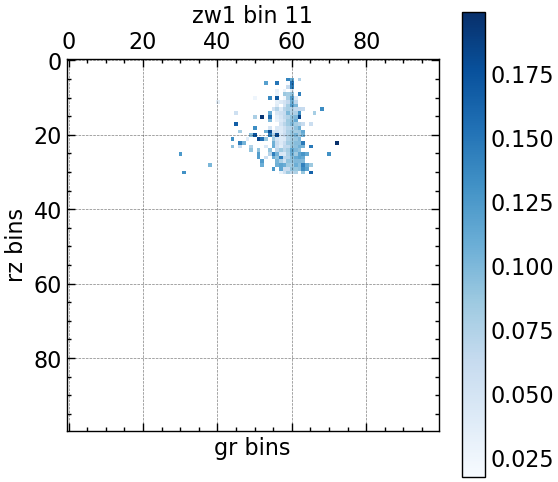

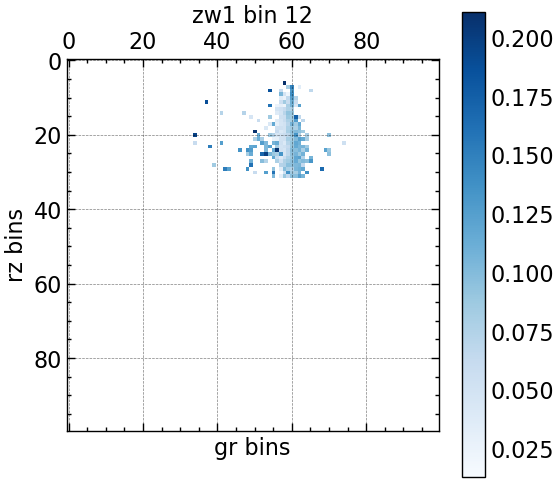

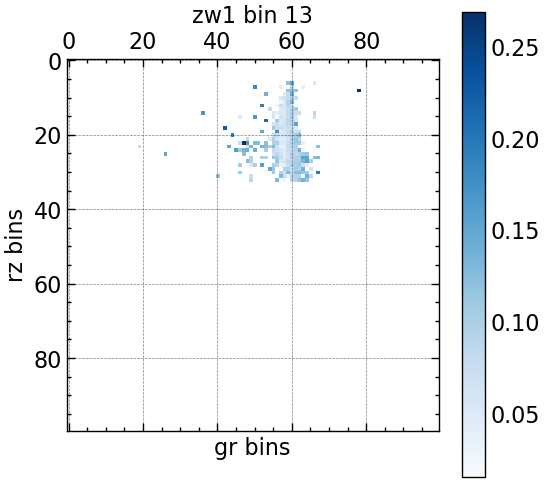

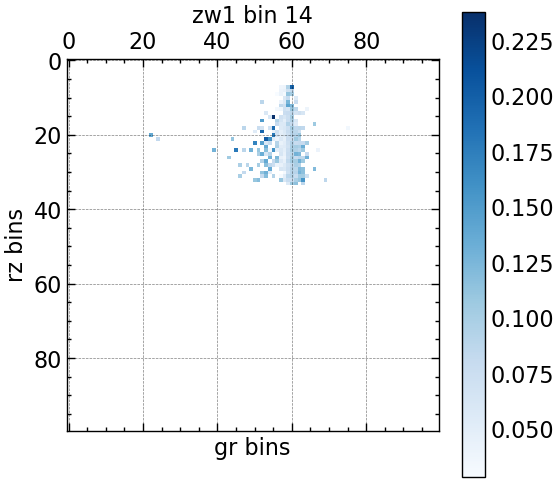

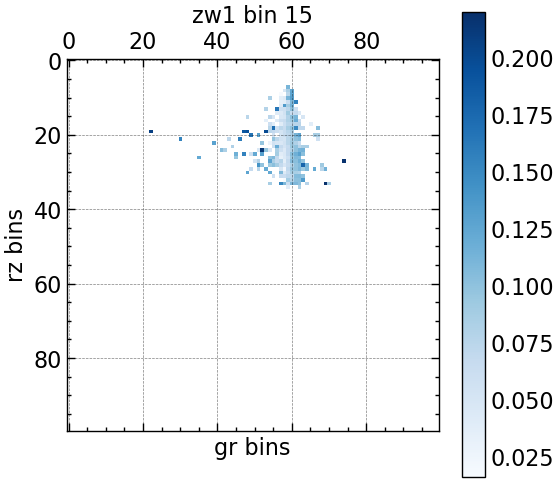

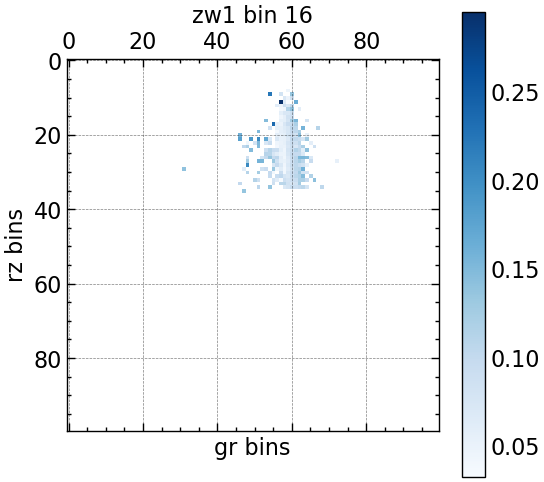

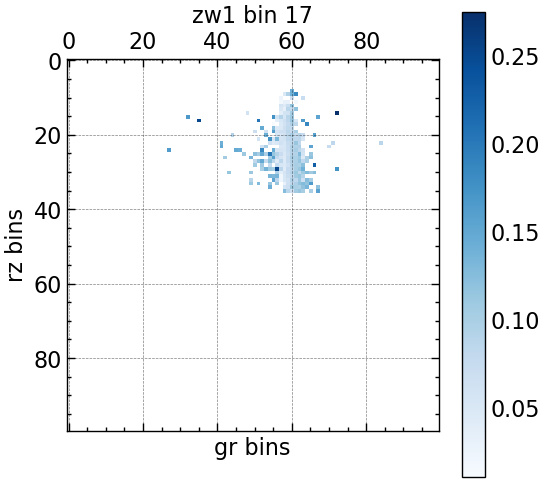

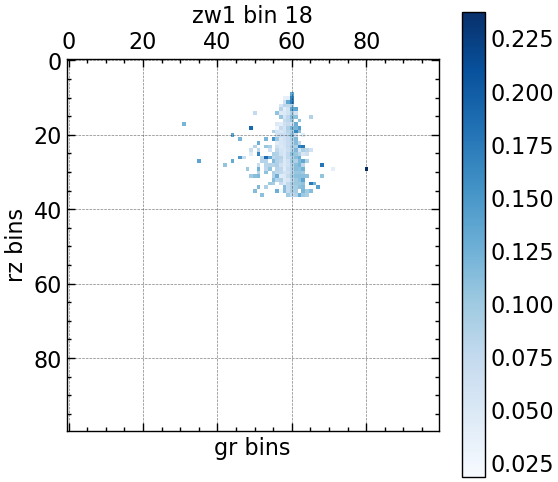

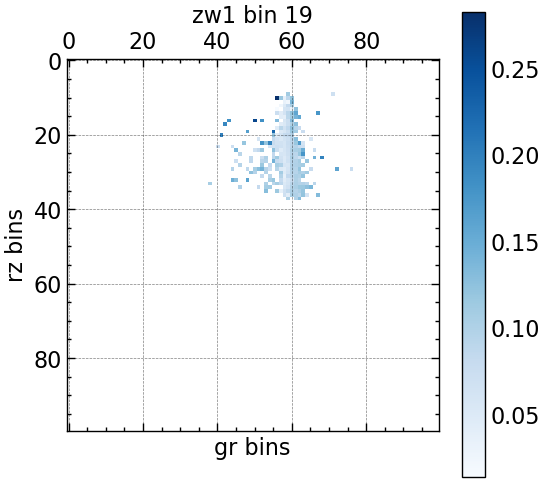

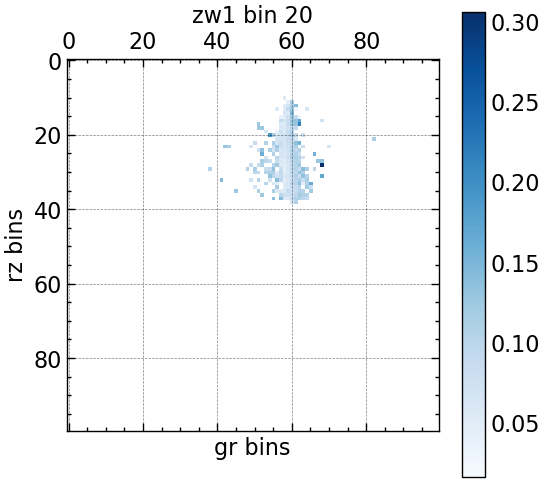

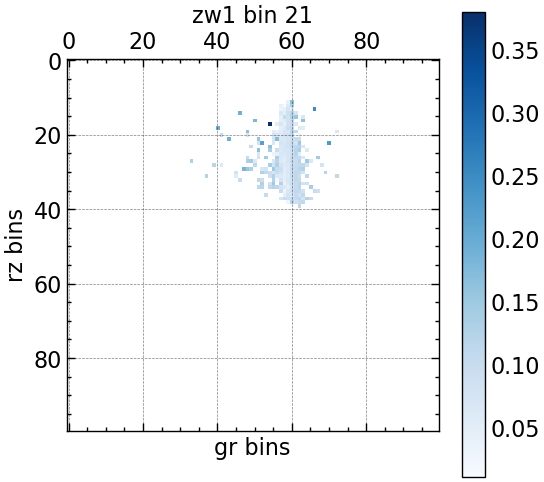

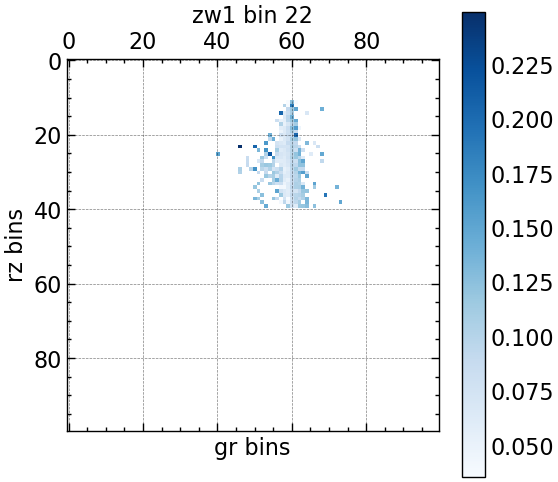

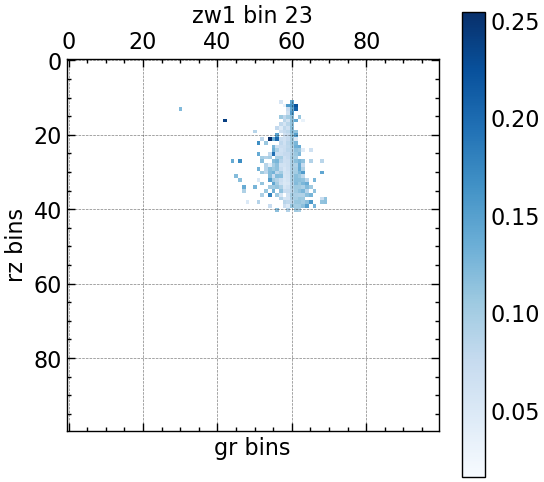

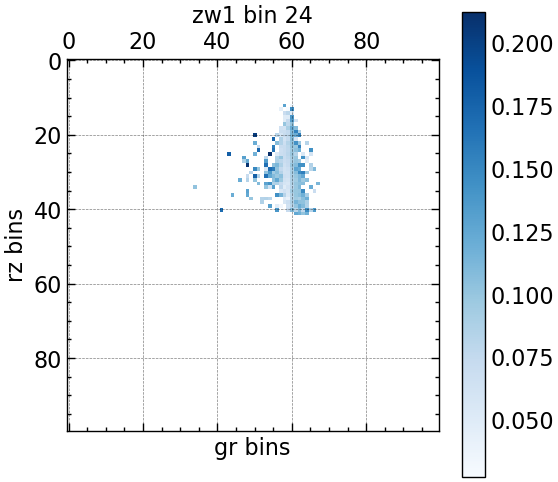

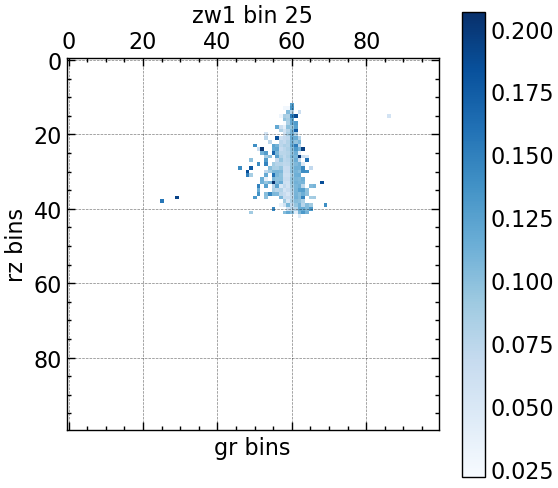

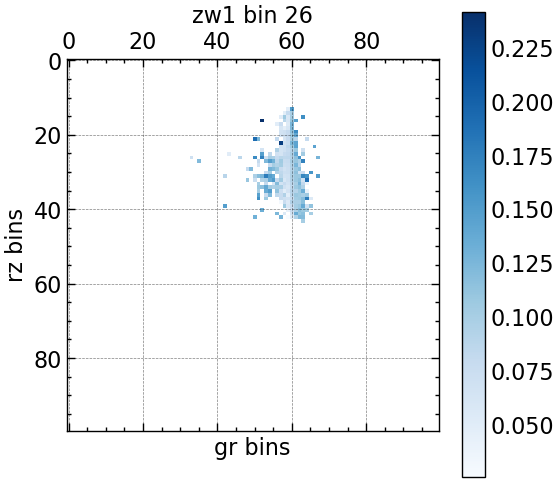

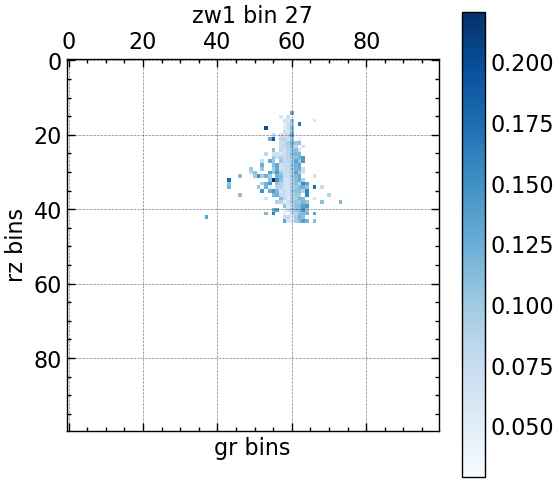

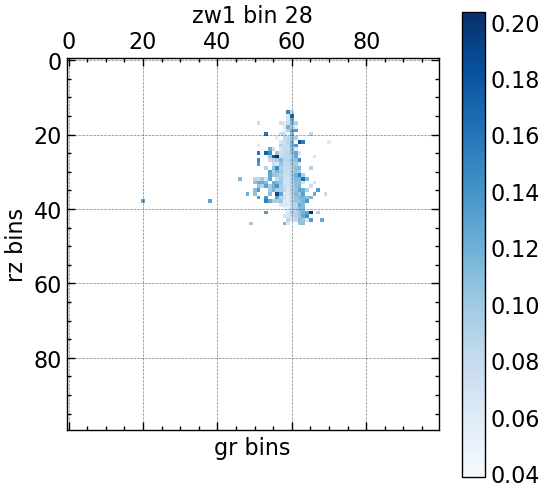

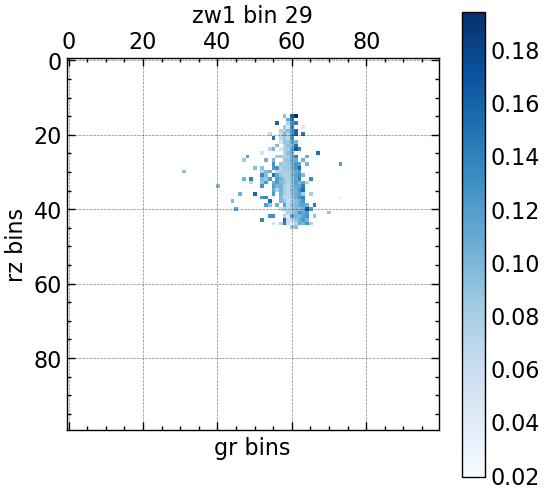

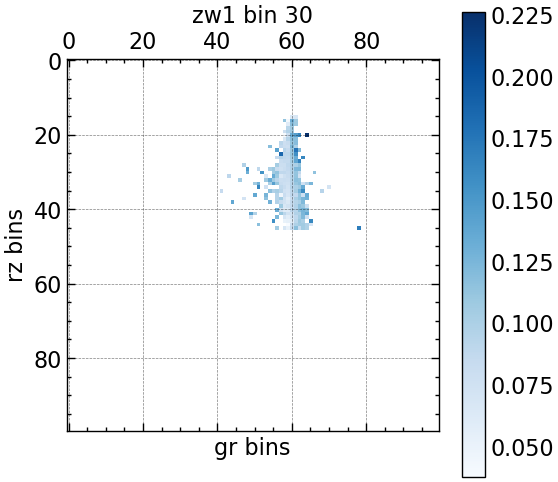

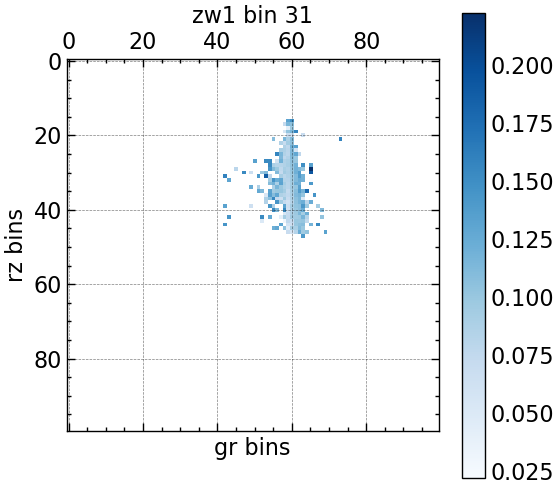

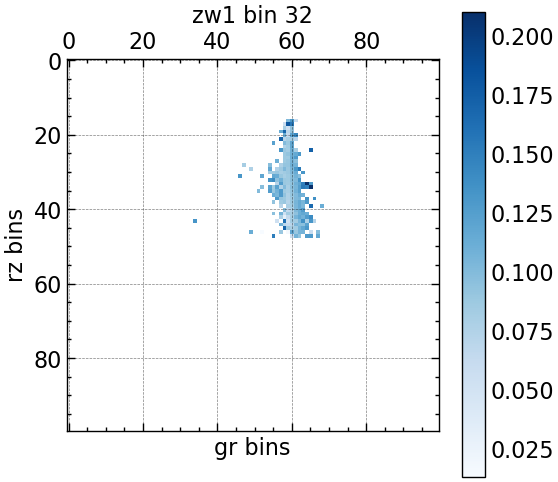

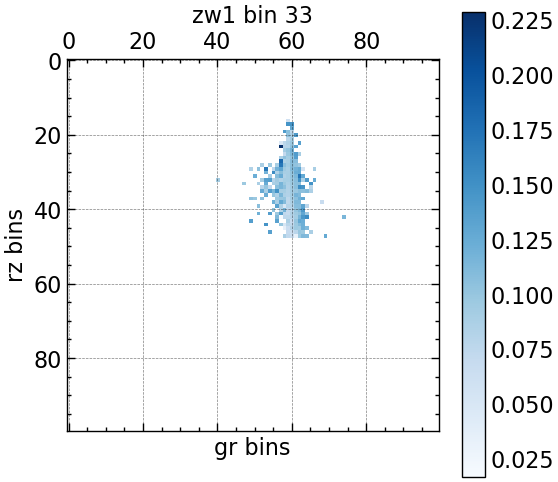

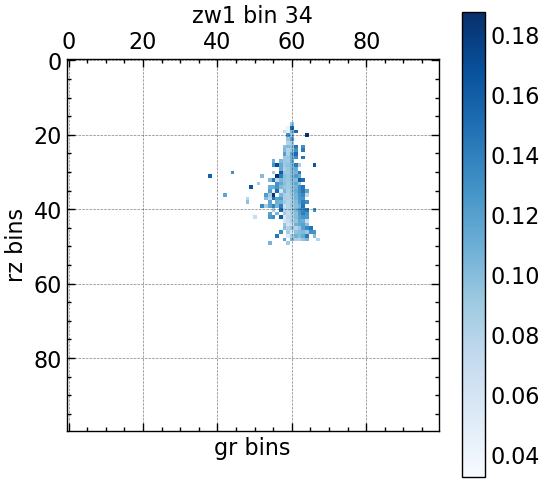

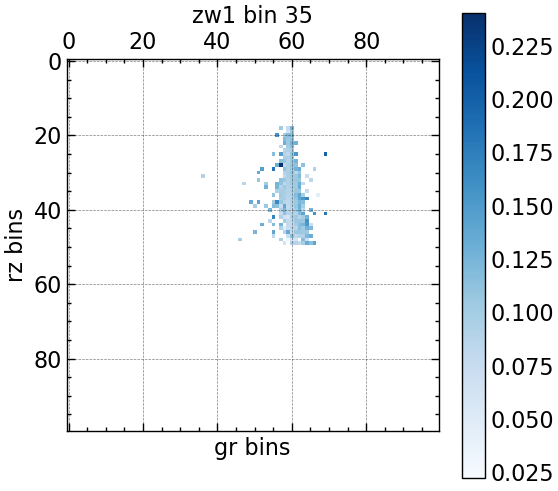

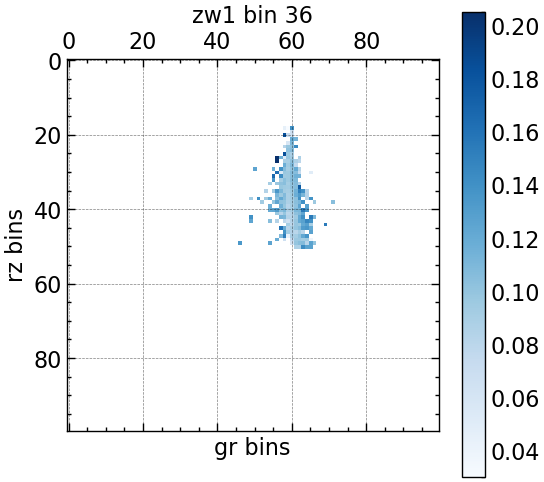

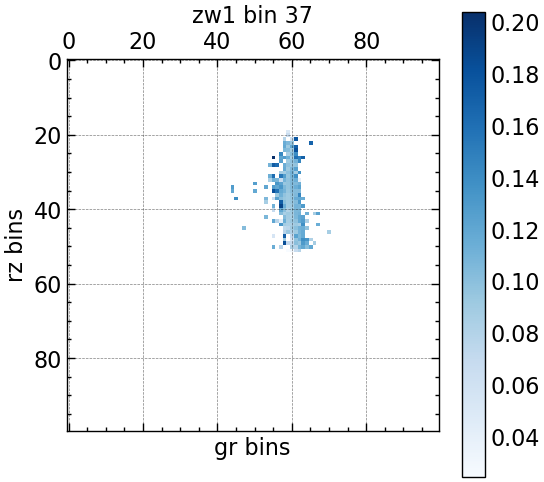

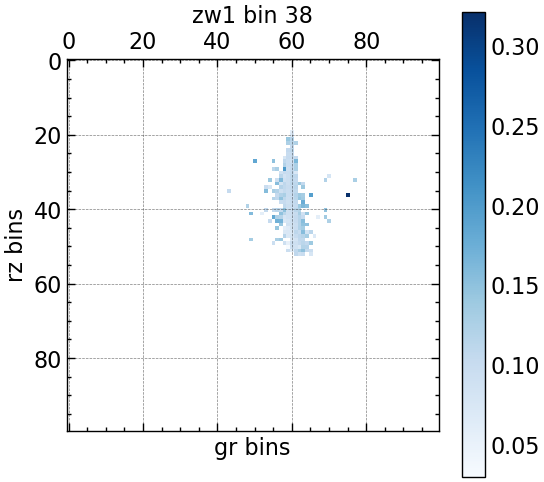

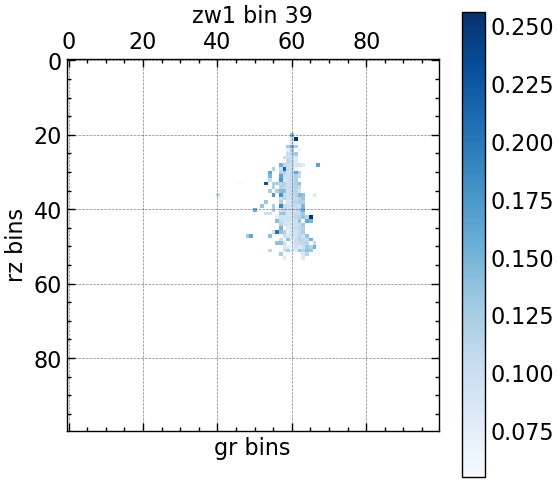

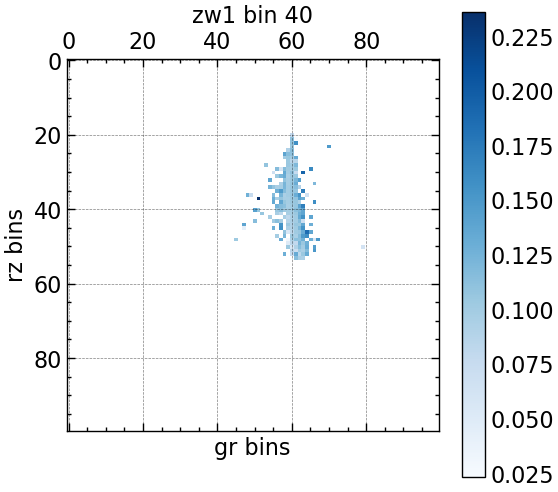

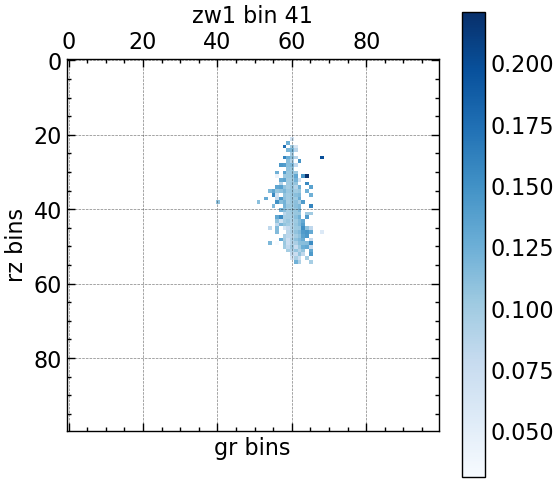

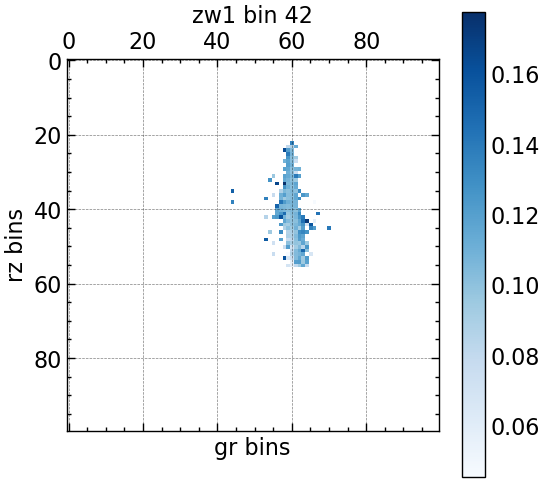

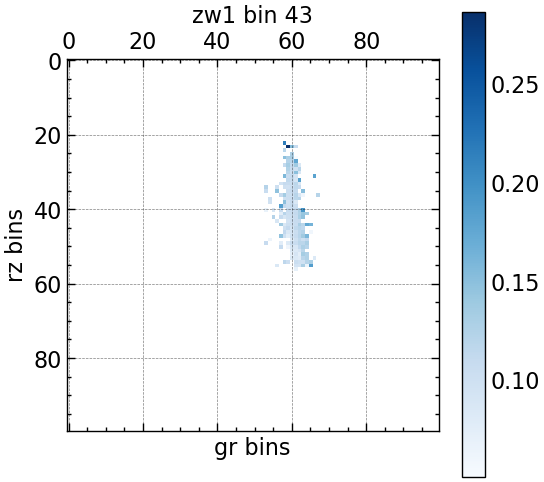

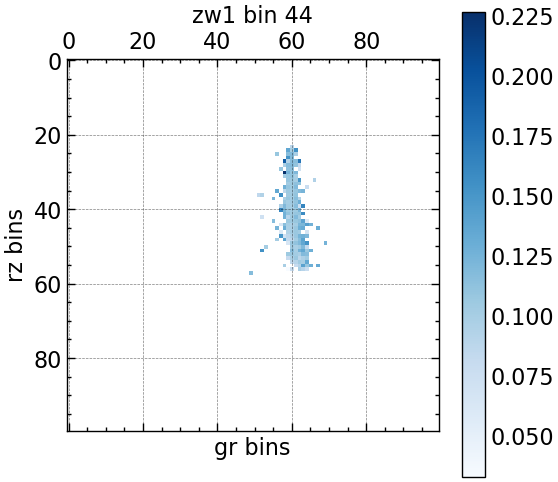

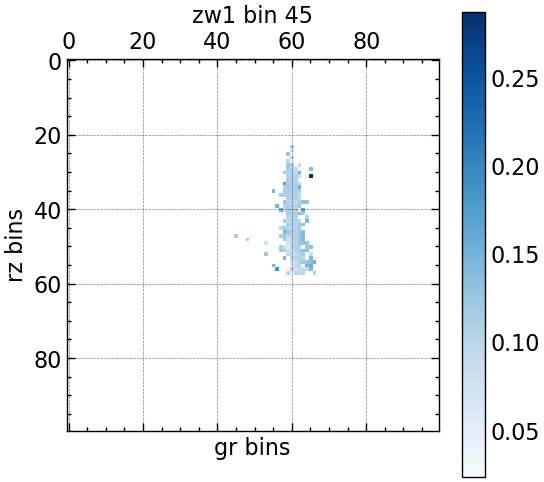

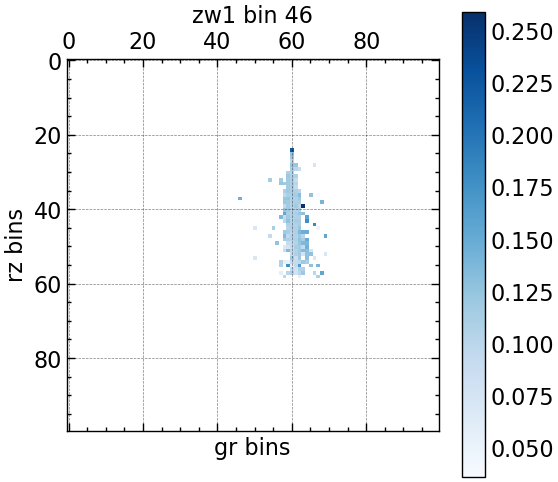

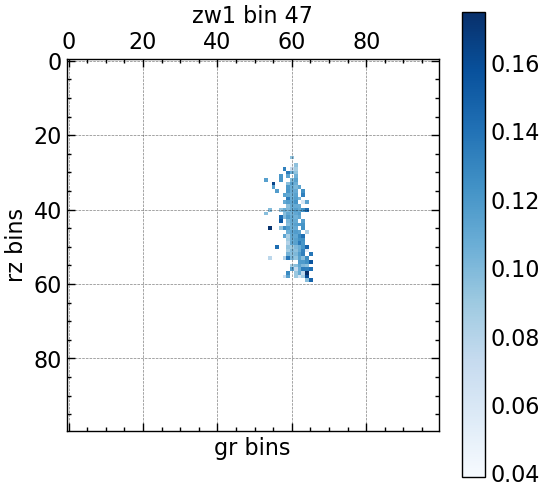

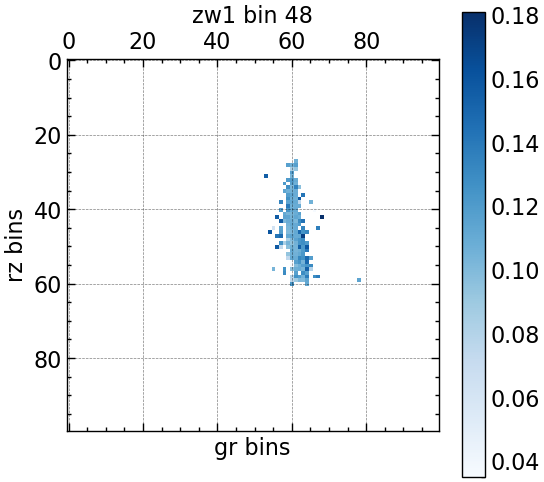

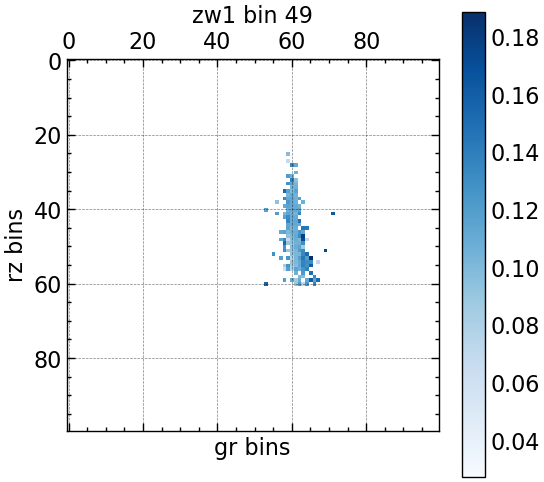

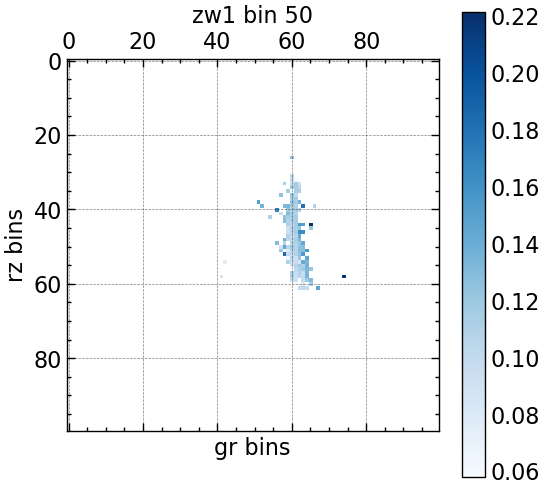

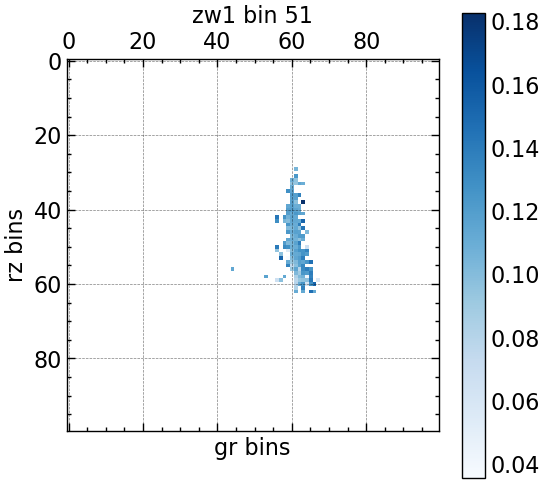

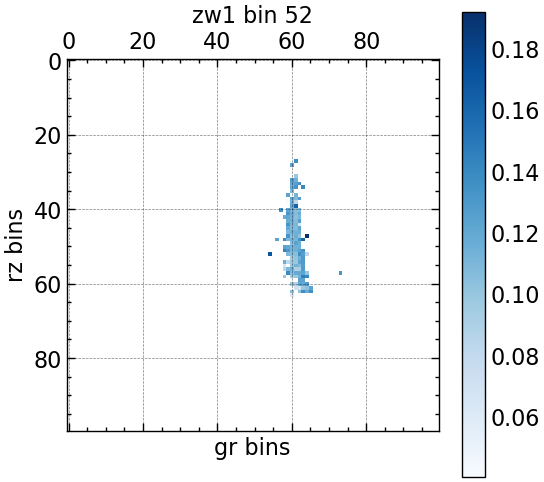

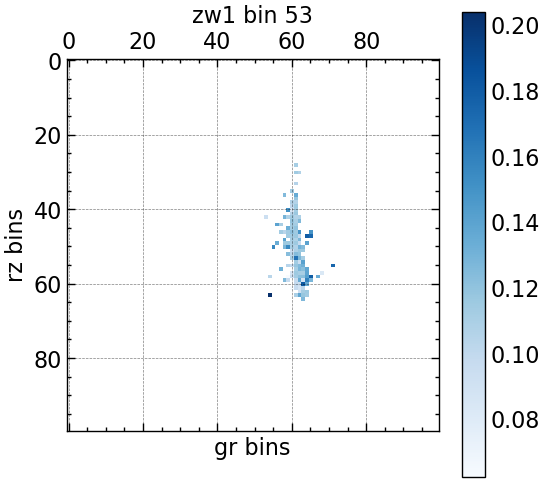

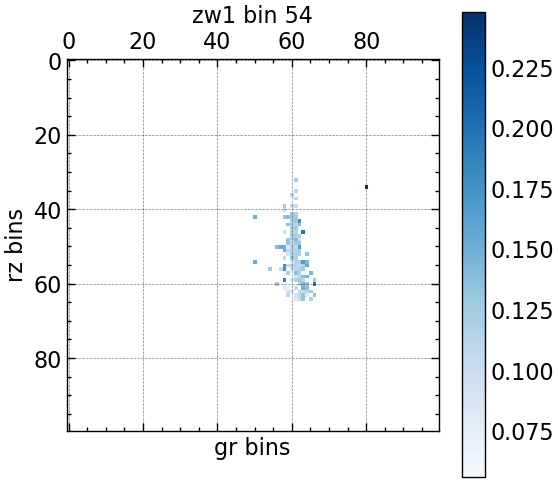

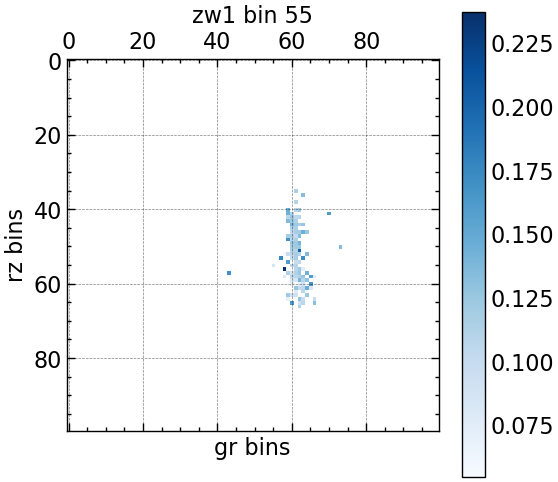

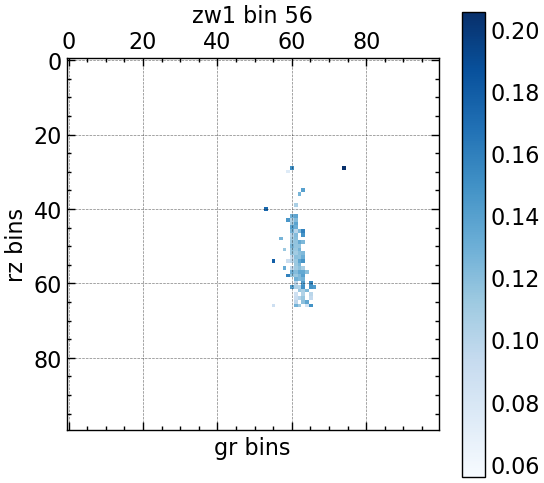

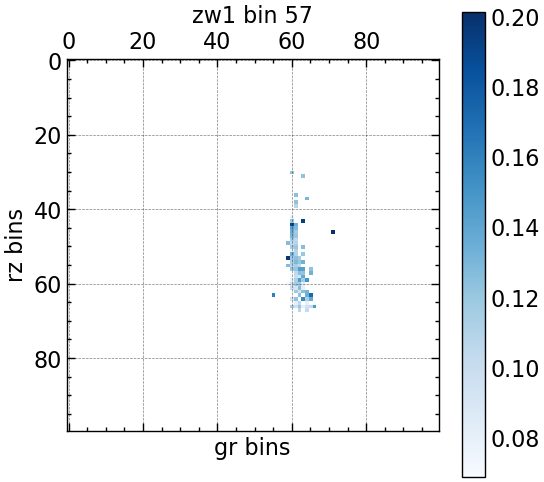

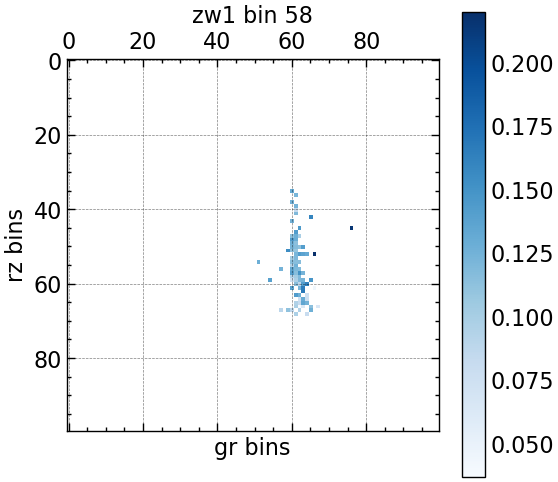

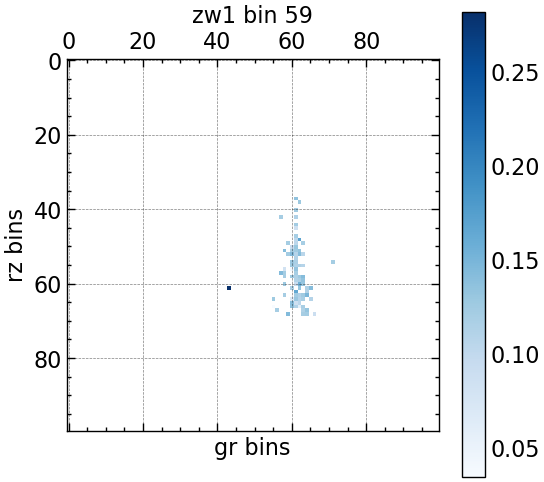

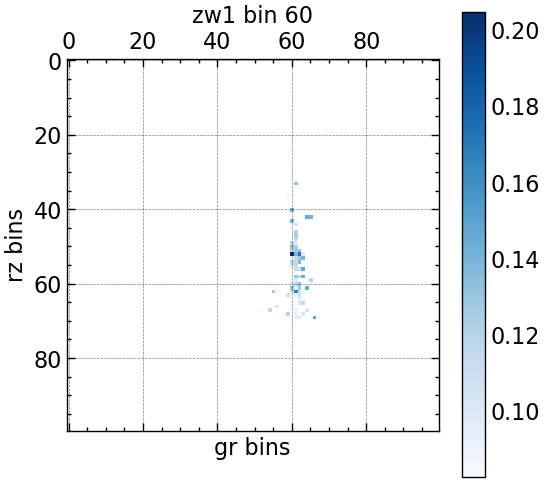

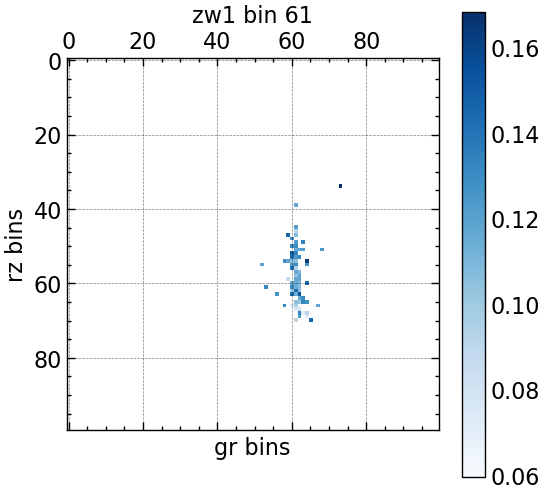

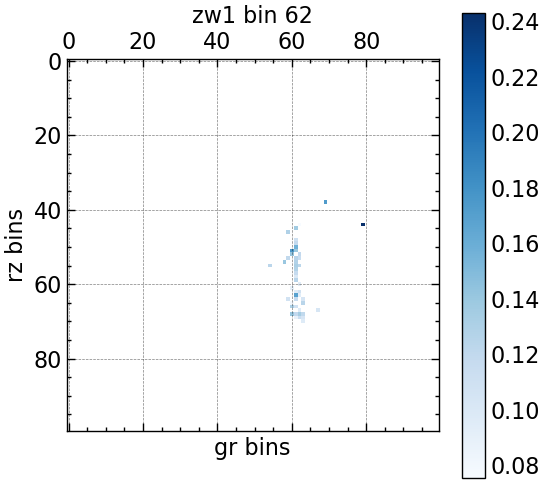

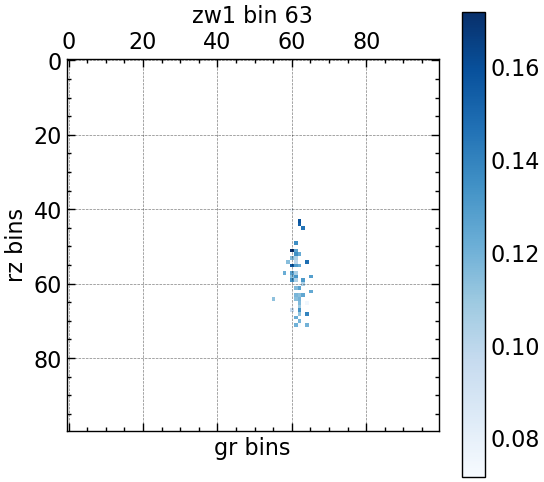

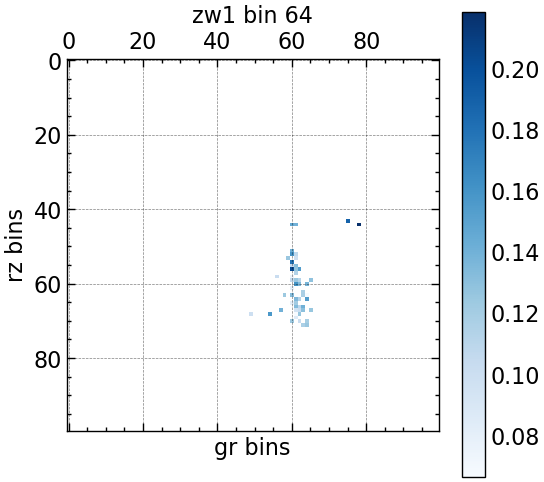

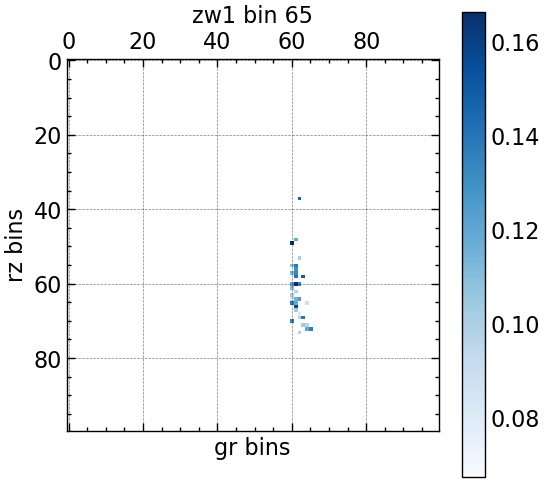

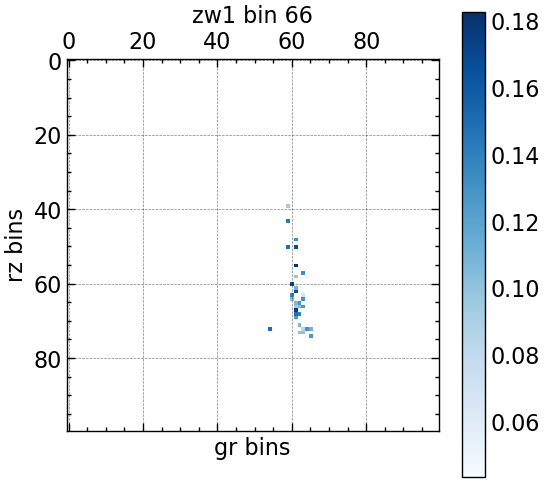

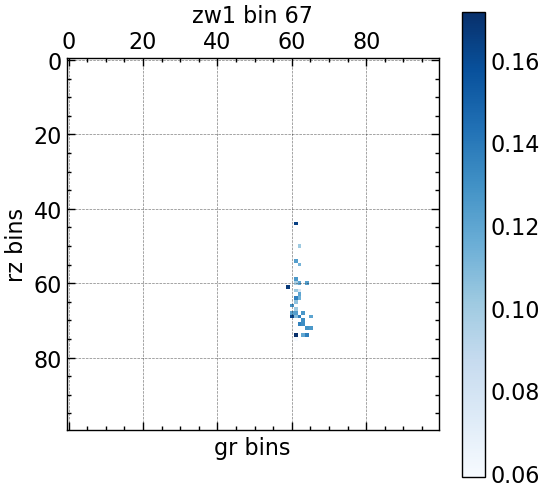

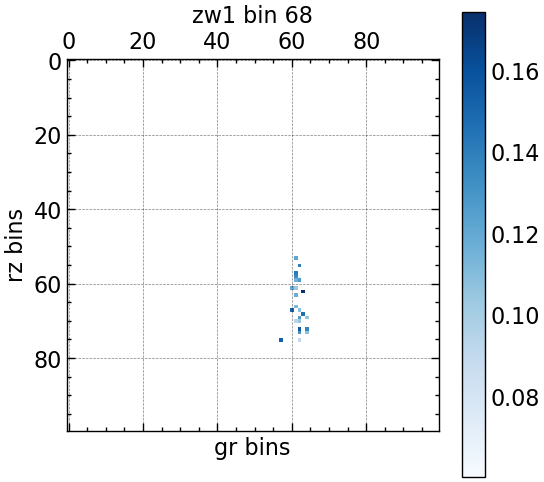

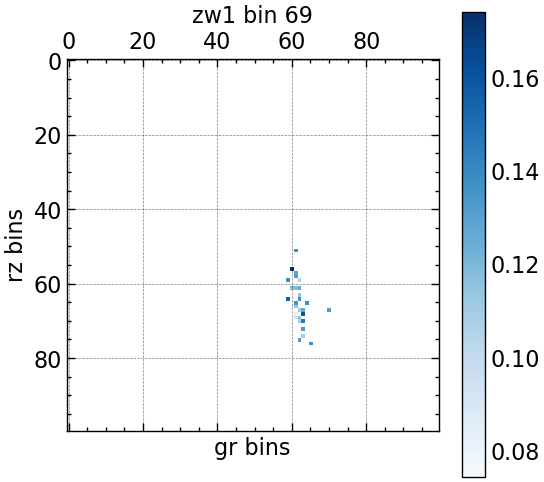

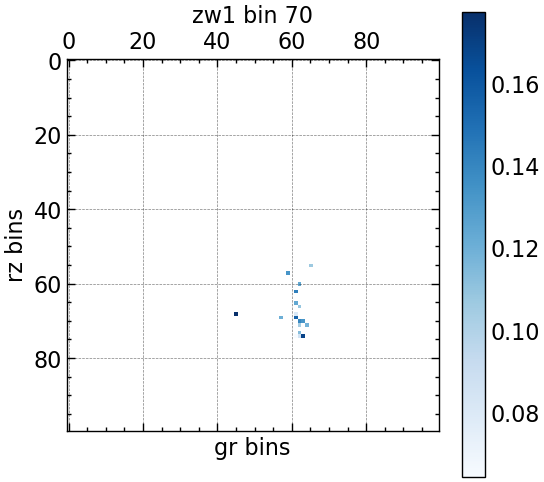

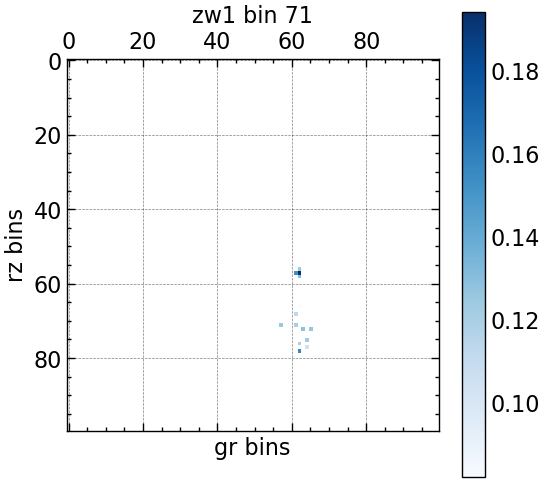

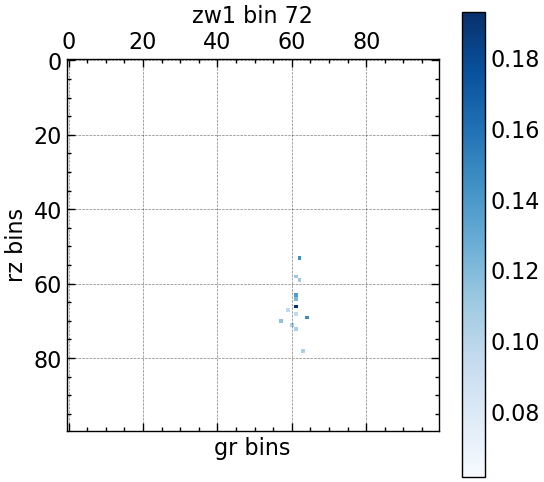

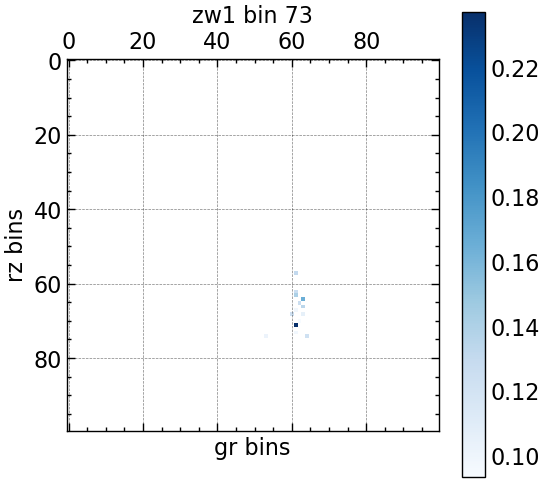

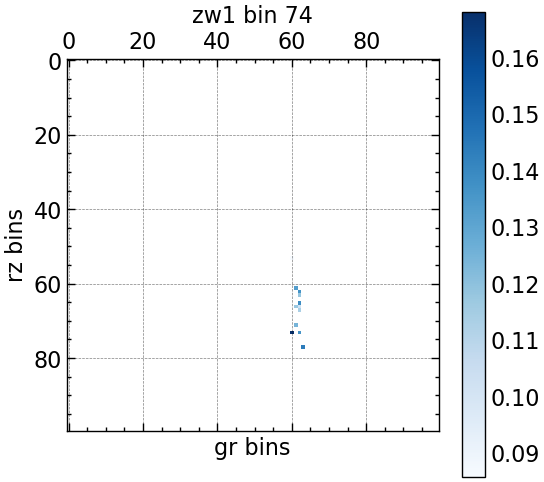

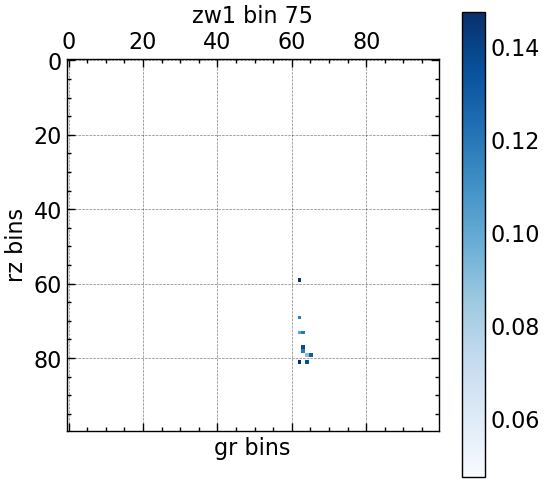

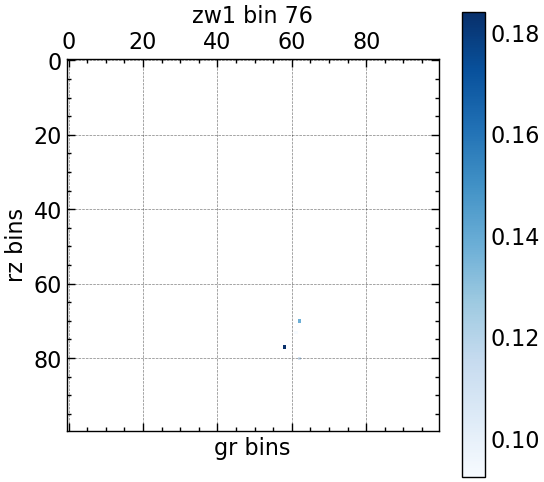

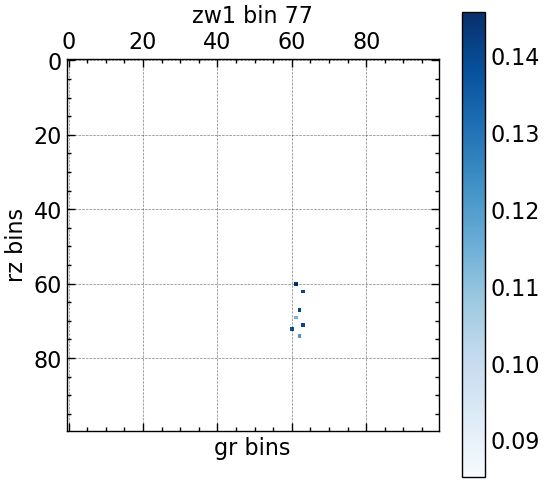

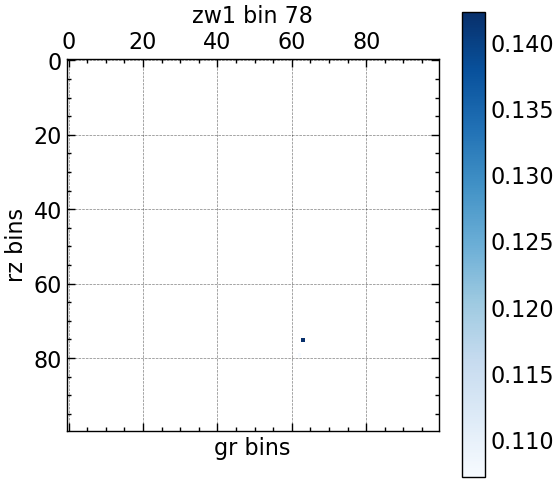

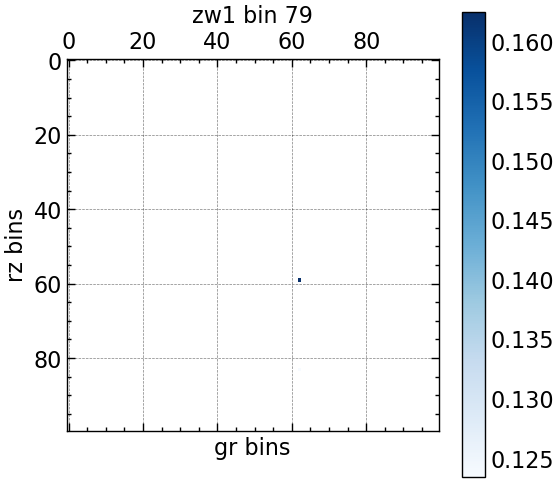

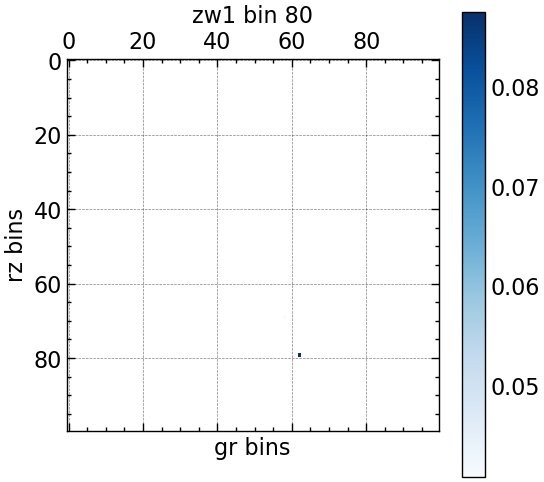

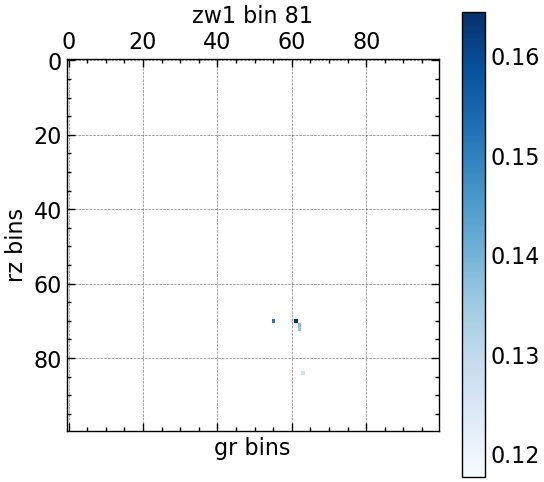

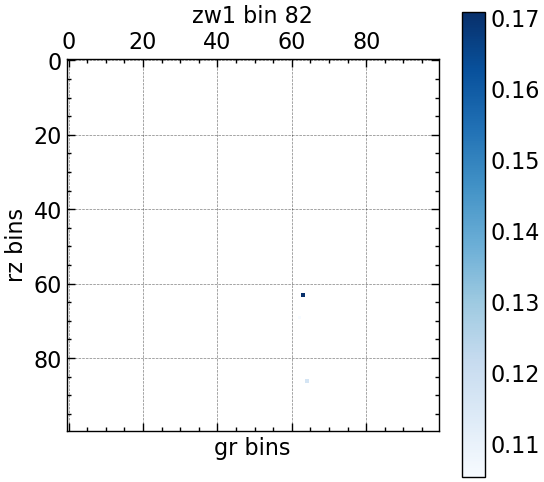

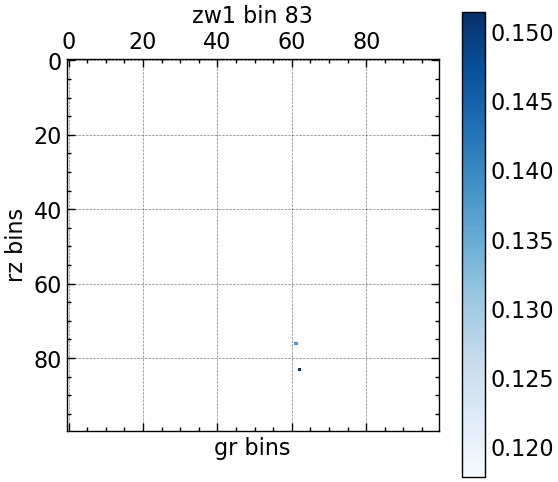

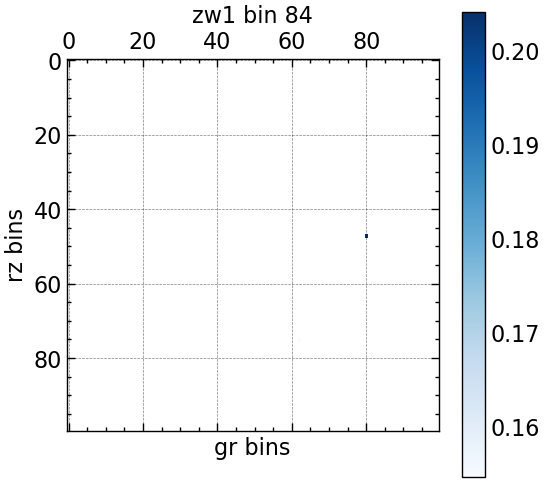

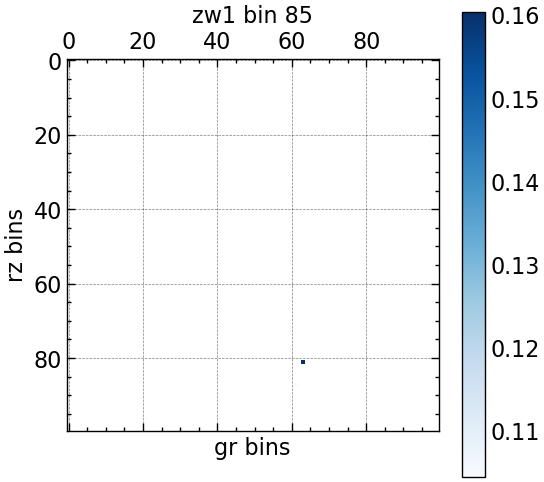

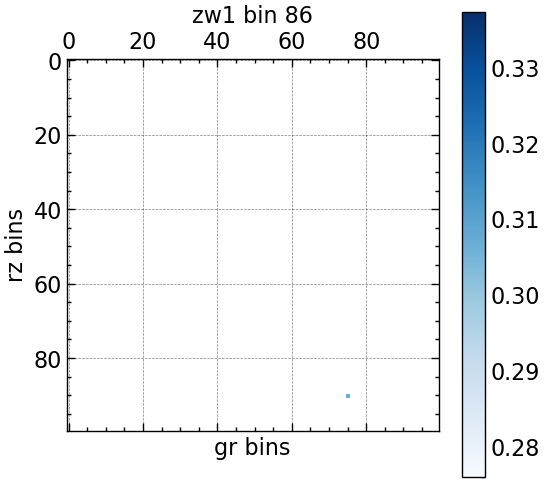

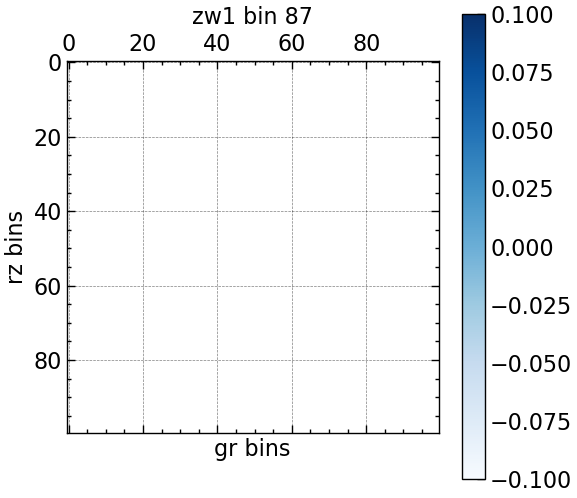

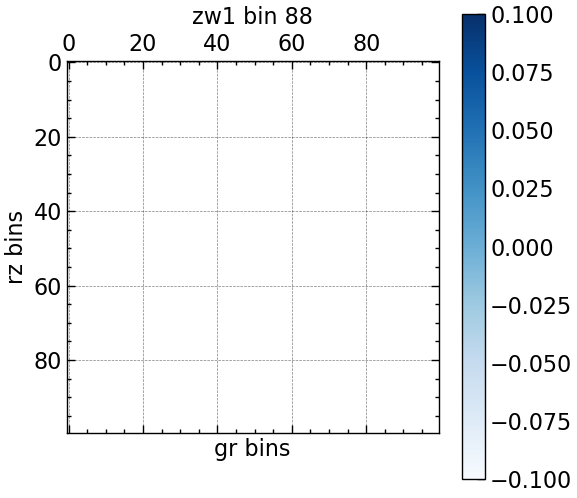

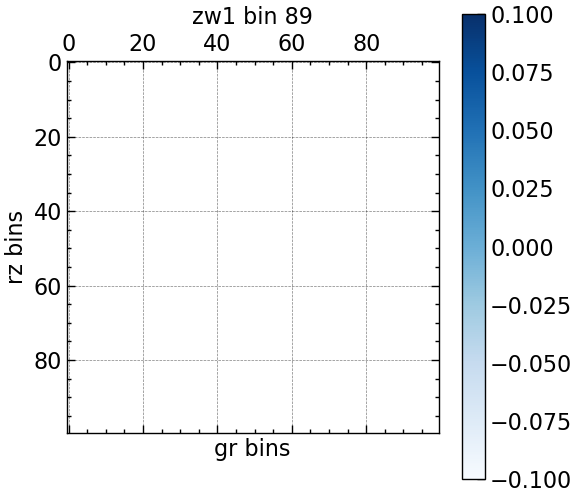

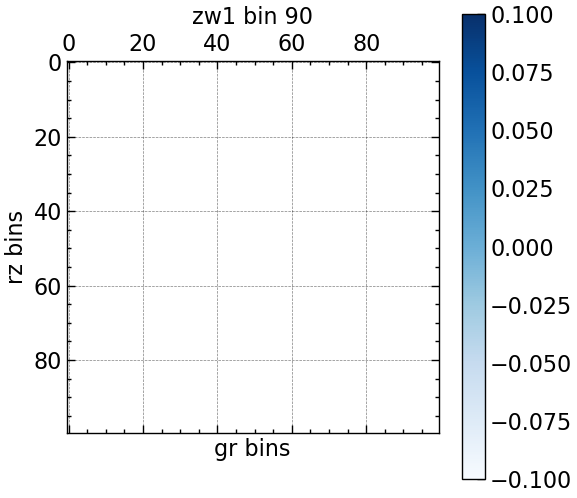

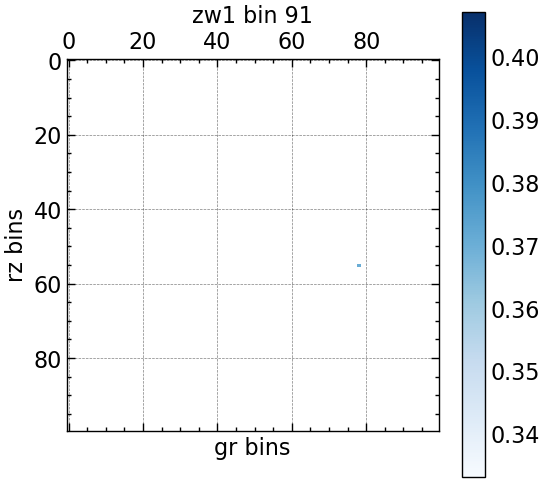

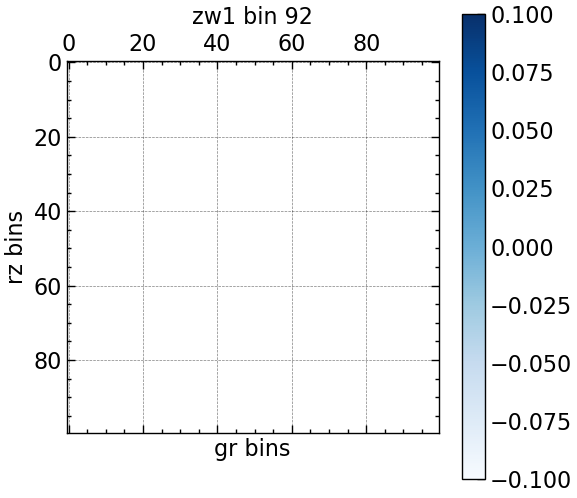

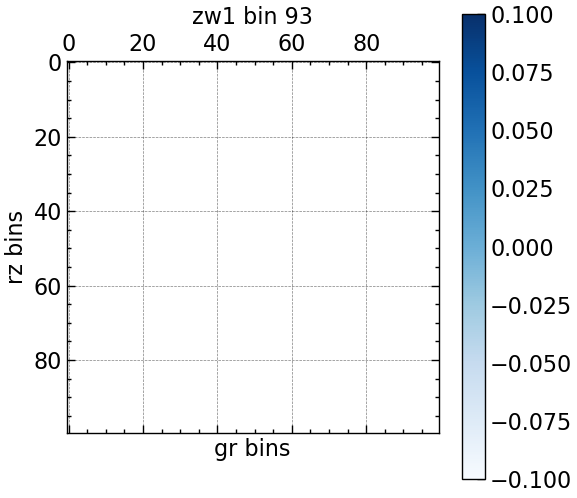

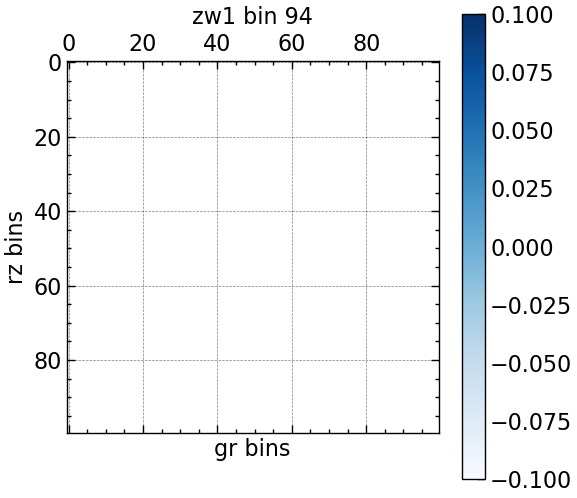

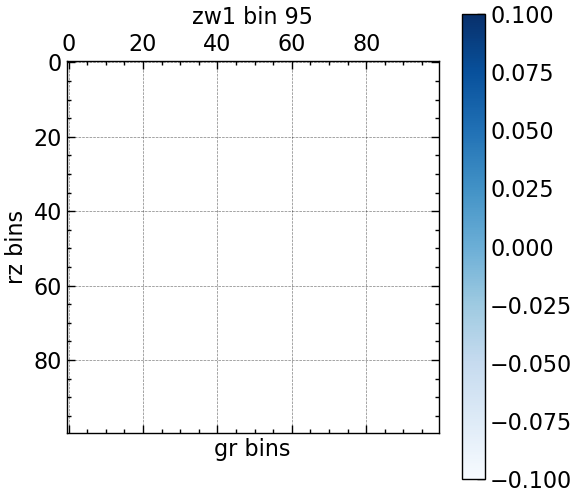

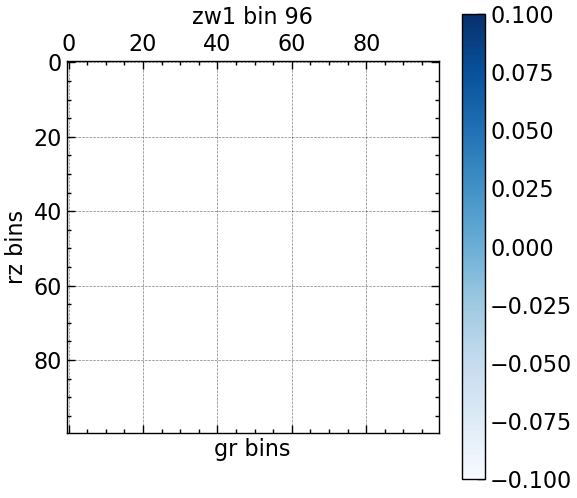

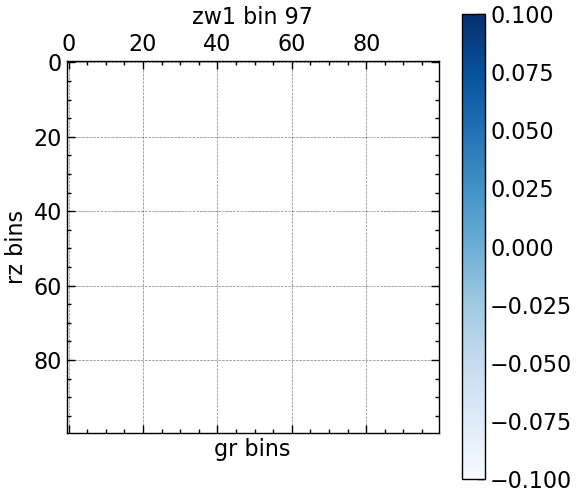

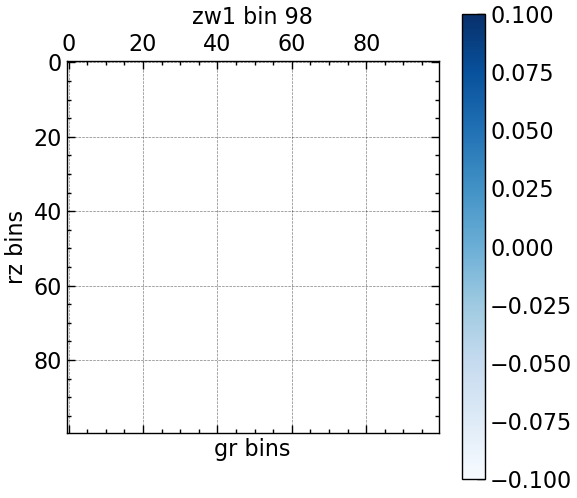

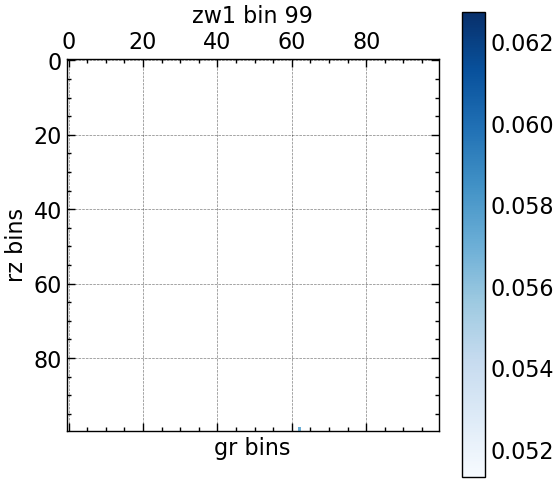

In [ ]:
for i in range(len(zmatrix_matrix)):
    plt.matshow(zmatrix_matrix[i,:,:],cmap='Blues')
    plt.colorbar()
    plt.title(f'zw1 bin {i}')
    plt.xlabel('gr bins')
    plt.ylabel('rz bins')
    plt.show()  

/tmp/ipykernel_4776/4020389795.py:4: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label="Counts summed over zw1")


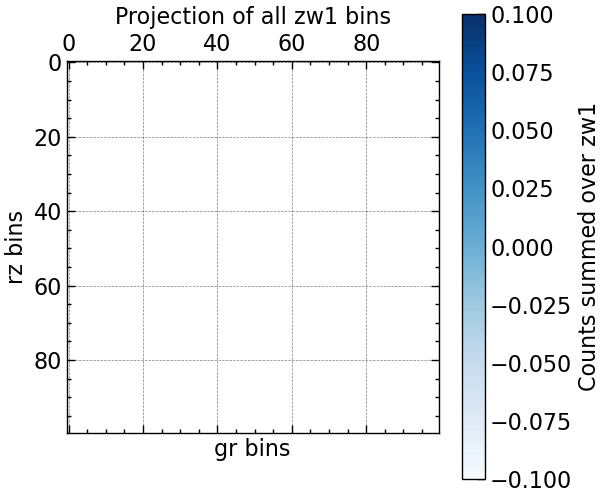

In [ ]:
collapsed = np.sum(zmatrix_matrix, axis=2)

plt.matshow(collapsed.T, cmap='Blues')
plt.colorbar(label="Counts summed over zw1")
plt.title("Projection of all zw1 bins")
plt.xlabel("gr bins")
plt.ylabel("rz bins")
plt.show()

In [ ]:
gr_bins


array([0.68000031, 0.74858189, 0.81716347, 0.88574505, 0.95432663,
       1.02290821, 1.09148979, 1.16007137, 1.22865295, 1.29723454,
       1.36581612])

In [ ]:
len(xcoord)

480728

In [ ]:
zmatrix=dat

gr_digit=np.digitize(xcoord,zmatrix1['gr_bins'])  
rz_digit=np.digitize(ycoord,zmatrix1['rz_bins'])  
zw1_digit=np.digitize(zcoord,zmatrix1['zw1_bins'])
gr_ind=(gr_digit>0) & (gr_digit<len(zmatrix1['gr_bins']))
rz_ind=(rz_digit>0) & (rz_digit<len(zmatrix1['rz_bins']))
zw1_ind=(zw1_digit>0) & (zw1_digit<len(zmatrix1['zw1_bins']))
ind=gr_ind*rz_ind*zw1_ind
zmatrix_3dcolor=zmatrix1['matrix']
inferz=np.ones(len(gr_digit))*(-1)
inferz[ind]=zmatrix_3dcolor[gr_digit[ind]-1,rz_digit[ind]-1,zw1_digit[ind]-1]
inferz[ind]+=np.random.uniform(high=1,low=-1,size=len(inferz[ind]))*0.001

In [ ]:
len(inferz)

480728

In [ ]:
binx = np.linspace(min(photo_z[inferz>0.001]), max(photo_z[inferz>0.001]), 100)
biny = np.linspace(min(inferz[inferz>0.001]), max(inferz[inferz>0.001]), 100)
hist,xedges,yedges=np.histogram2d(photo_z[inferz>0.001], inferz[inferz>0.001   ], bins=(binx, biny))


/tmp/ipykernel_4776/2204561602.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()


Text(0, 0.5, 'Inferred z from 3D color')

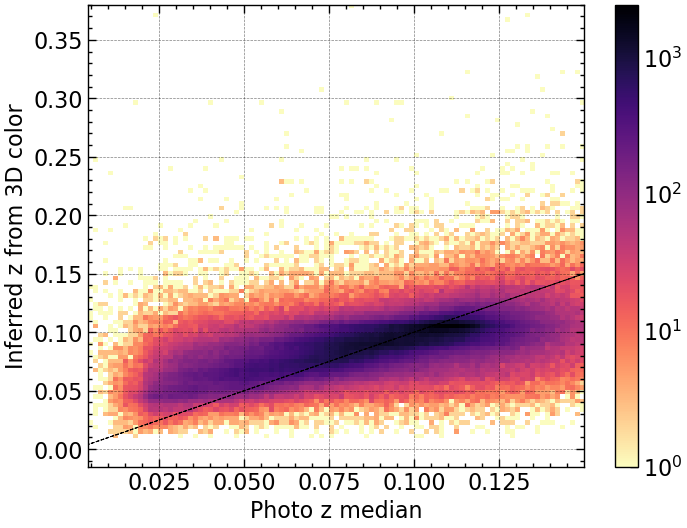

In [ ]:
from matplotlib.colors import LogNorm
plt.imshow(hist.T, origin='lower',
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='auto',cmap='magma_r',norm=LogNorm())

plt.plot(photo_z[inferz>0.001],photo_z[inferz>0.001],'k--',lw=0.7)
plt.colorbar()
plt.xlabel('Photo z median')
plt.ylabel('Inferred z from 3D color')

Text(0, 0.5, 'Inferred z from 3D color')

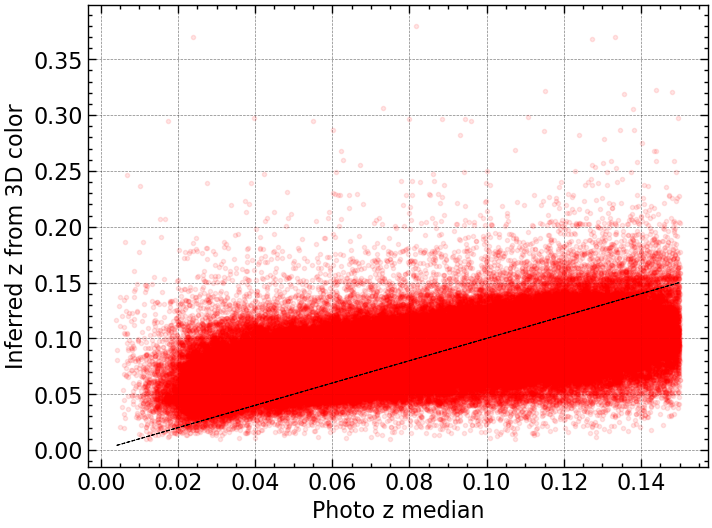

In [ ]:
plt.plot(photo_z[inferz>0.001],inferz[inferz>0.001],'r.',alpha=0.1)
plt.plot(photo_z[inferz>0.001],photo_z[inferz>0.001],'k--',lw=0.7)
plt.xlabel('Photo z median')
plt.ylabel('Inferred z from 3D color')
#plt.ylim(0,0.15)

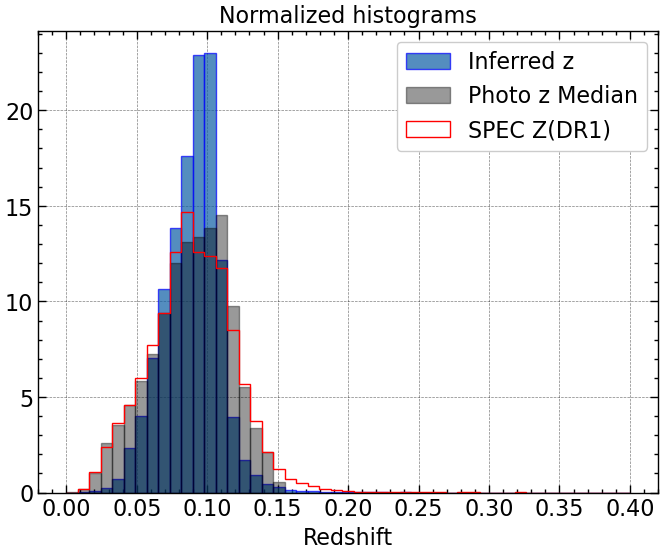

In [ ]:
bins = np.linspace(-0, 0.4, 50)
plt.title('Normalized histograms')
plt.hist(inferz,bins=bins,alpha=0.7,edgecolor='b',label ='Inferred z',density=True)
plt.hist(photo_z,bins=bins,alpha=0.4,edgecolor='k',color='k',label ='Photo z Median',density=True)
plt.hist(matched_dr['Z'],bins=bins,alpha=1,edgecolor='r',color='k',label ='SPEC Z(DR1)',density=True,histtype='step')
plt.xlabel('Redshift')
plt.legend()


0.3792606509357796

In [ ]:
max(inferz)

0.37847085372389794

In [ ]:
max(photo_z)

0.14999881

In [16]:
north_DR1=Table(fitsio.FITS('../TABLE_DR1_north_v1_sep_1.fits')[1].read())
south_DR1=Table(fitsio.FITS('../TABLE_DR1_south_v1_sep_1.fits')[1].read())
DR1=vstack([north_DR1,south_DR1])

In [17]:
north_legacy = Table(fitsio.FITS('../TABLE_legacy_north_v1_sep_1.fits')[1].read())
south_legacy = Table(fitsio.FITS('../TABLE_legacy_south_v1_sep_1.fits')[1].read())
legacy = vstack([north_legacy,south_legacy])

In [35]:
np.isfinite(DR1['Z'])

array([ True,  True,  True, ...,  True,  True,  True])

In [30]:
mask = (legacy['FLUX_G'] != 0) & (legacy['FLUX_R'] != 0) & (legacy['FLUX_Z'] != 0)
legacy_filtered = legacy[mask]
print(len(legacy_filtered))
data = np.array([legacy_filtered[col] for col in legacy_filtered.colnames]).T
mask = np.all(np.isfinite(data), axis=1)
legacy_filtered = legacy_filtered[mask]
print(len(legacy-filtered))

KeyboardInterrupt: 

In [33]:
numeric_cols = [c for c in legacy.colnames if np.issubdtype(legacy[c].dtype, np.number)]
arr = np.vstack([legacy[c] for c in numeric_cols])   # shape = (ncols, nrows)

mask = np.isfinite(arr).all(axis=0)   # check all cols at once
legacy_filtered = legacy[mask]

KeyboardInterrupt: 

In [1]:
len(legacy)-np.count_nonzero(legacy['FLUX_Z']==0)

NameError: name 'legacy' is not defined

In [27]:
MAG = {}
FIBERMAG = {}
MAG_NOEXT={}
for i in ['G','R','Z','W1','W2','W3']:
    flux = np.array(legacy[f'FLUX_{i}'])
    trans = np.array(legacy[f'MW_TRANSMISSION_{i}'])
    frac = flux / trans
    mag = np.empty_like(frac)
    mag_noext= np.empty_like(frac)
    np.log10(flux, out=mag_noext, where=(frac > 0))
    np.log10(frac, out=mag, where=(frac > 0))
    MAG[i] = 22.5 - 2.5 * mag
    MAG_NOEXT[i] = 22.5 - 2.5 * mag_noext
# for i in ['G','R','Z']:
#     fiberflux= np.array(dr9_chunk[f'FIBERFLUX_{i}'])
#     trans = np.array(dr9_chunk[f'MW_TRANSMISSION_{i}'])
#     fracfiber= fiberflux /trans
#     magfiber = np.empty_like(fracfiber)
#     np.log10(fracfiber, out=magfiber, where=(fracfiber > 0))
#     FIBERMAG[i] = 22.5 - 2.5 * magfiber

# Compute r_circ


legacy['MAG_G'] = MAG['G']
legacy['MAG_R'] = MAG['R']
legacy['MAG_Z'] = MAG['Z']
legacy['MAG_W1'] = MAG['W1']
legacy['MAG_W2'] = MAG['W2']
legacy['MAG_W3'] = MAG['W3']


legacy['MAG_GR'] = legacy['MAG_G'] - legacy['MAG_R']
legacy['MAG_RZ'] = legacy['MAG_R'] - legacy['MAG_Z']
legacy['MAG_GZ'] = legacy['MAG_G'] - legacy['MAG_Z']
legacy['MAG_W1W2'] = legacy['MAG_W1'] - legacy['MAG_W2']
legacy['MAG_W2W3'] = legacy['MAG_W2'] - legacy['MAG_W3']
legacy['MAG_W1W3'] = legacy['MAG_W1'] - legacy['MAG_W3']
legacy['MAG_RW1'] = legacy['MAG_R'] - legacy['MAG_W1']
legacy['MAG_RW2'] = legacy['MAG_R'] - legacy['MAG_W2']
legacy['MAG_RW3'] = legacy['MAG_R'] - legacy['MAG_W3']
legacy['MAG_GW1'] = legacy['MAG_G'] - legacy['MAG_W1']
legacy['MAG_GW3'] = legacy['MAG_G'] - legacy['MAG_W3']
legacy['MAG_GW2'] = legacy['MAG_G'] - legacy['MAG_W2']
legacy['MAG_ZW1'] = legacy['MAG_Z'] - legacy['MAG_W1']
legacy['MAG_ZW2'] = legacy['MAG_Z'] - legacy['MAG_W2']
legacy['MAG_ZW3'] = legacy['MAG_Z'] - legacy['MAG_W3']







In [13]:
legacy['Z'] = DR1['Z']

In [ ]:
ml_data

NameError: name 'ml_data' is not defined

In [6]:
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [ ]:
ml_data

NameError: name 'ml_data' is not defined

In [ ]:
ml_data

In [14]:
ml_data = np.array(legacy[['MAG_G', 'MAG_R', 'MAG_Z', 'MAG_W1', 'MAG_GR', 'MAG_RZ', 'MAG_ZW1','SHAPE_R']])
ml_data_og = np.copy(ml_data )
ml_pred = np.array(legacy['Z'])

ml_data = np.vstack([list(row) for row in ml_data])

X_train, X_test, y_train, y_test = train_test_split(ml_data, ml_pred, test_size=0.2, random_state=42)

In [ ]:
model = CatBoostRegressor(
    iterations=5000,        # number of boosting rounds
    depth=8,               # tree depth
    learning_rate=0.4,     # shrinkage rate
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=100            # print progress every 100 iters
)

In [ ]:
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

0:	learn: 0.1004370	test: 0.1005015	best: 0.1005015 (0)	total: 128ms	remaining: 10m 37s
100:	learn: 0.0445950	test: 0.0445913	best: 0.0445913 (100)	total: 6.71s	remaining: 5m 25s
200:	learn: 0.0430506	test: 0.0430732	best: 0.0430732 (200)	total: 13.2s	remaining: 5m 15s
300:	learn: 0.0425398	test: 0.0425848	best: 0.0425848 (300)	total: 19.5s	remaining: 5m 5s
400:	learn: 0.0422745	test: 0.0423398	best: 0.0423398 (400)	total: 25.9s	remaining: 4m 57s
500:	learn: 0.0421051	test: 0.0421915	best: 0.0421915 (500)	total: 32.5s	remaining: 4m 51s
600:	learn: 0.0419819	test: 0.0420898	best: 0.0420898 (600)	total: 39s	remaining: 4m 45s
700:	learn: 0.0418885	test: 0.0420170	best: 0.0420170 (700)	total: 45.3s	remaining: 4m 37s
800:	learn: 0.0418053	test: 0.0419523	best: 0.0419523 (800)	total: 51.8s	remaining: 4m 31s
900:	learn: 0.0417428	test: 0.0419092	best: 0.0419092 (900)	total: 58.3s	remaining: 4m 25s
1000:	learn: 0.0416895	test: 0.0418737	best: 0.0418737 (1000)	total: 1m 4s	remaining: 4m 17s
110

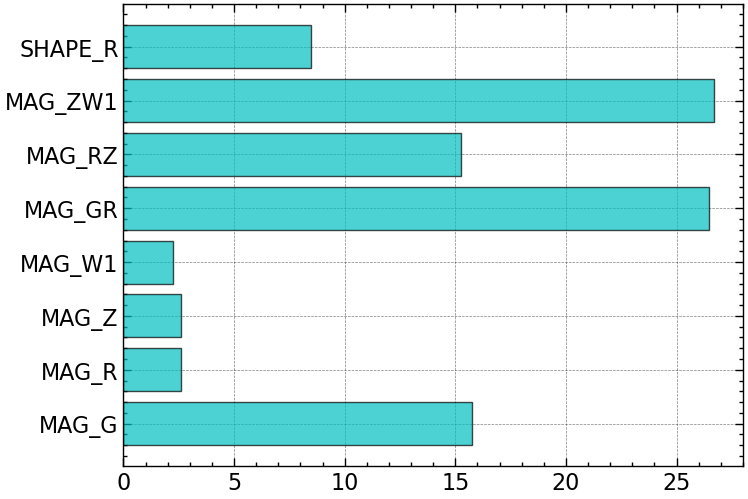

In [ ]:
import matplotlib.pyplot as plt

feature_importances = model.get_feature_importance()
feature_names = ml_data_og.dtype.names
plt.barh(feature_names, feature_importances,alpha=0.7,color='c',edgecolor='k')
plt.show()

In [ ]:
from catboost import cv, Pool

cv_data = cv(
    Pool(X, y),
    params=model.get_params(),
    fold_count=5,
    early_stopping_rounds=200,
    verbose=100
)


NameError: name 'X' is not defined

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from catboost import cv, Pool

cv_data = cv(
    Pool(X, y),
    params=model.get_params(),
    fold_count=5,
    early_stopping_rounds=200,
    verbose=100
)

In [ ]:
def save_with_increment(df, filename):
    path = Path(filename)
    stem, suffix = path.stem, path.suffix

    counter = 0
    new_path = path
    while new_path.exists():
        counter += 1
        new_path = path.with_name(f"{stem}_{counter}{suffix}")

    df.to_csv(new_path, index=False)
    print(f"Saved to {new_path}")
save_with_increment(cv_data, "cv_results_.csv")